In [6]:
#DOWNLOADING THE DATASET ACS19955
from google.colab import drive
import requests
import os
from tqdm.auto import tqdm
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:

#UNCOMMENT WHEN DOING FOR THE FIRST TIME


# Official ACS19955 Figshare dataset
ARTICLE_ID = 29925314
API_URL = f"https://api.figshare.com/v2/articles/{ARTICLE_ID}"

# Download directly to Google Drive
RAW_DIR = "/content/drive/MyDrive/ECG_Project/ACS19955/raw"
os.makedirs(RAW_DIR, exist_ok=True)

article = requests.get(API_URL).json()

for file_info in article["files"]:
    filename = file_info["name"]
    url = file_info["download_url"]
    output_path = os.path.join(RAW_DIR, filename)

    print(f"\nDownloading: {filename}")

    response = requests.get(url, stream=True)
    response.raise_for_status()

    total = int(response.headers.get("content-length", file_info["size"]))

    with open(output_path, "wb") as f:
        with tqdm(
            total=total,
            unit="B",
            unit_scale=True,
            desc=filename
        ) as pbar:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))

print("\nDataset downloaded successfully.")
print("Location:", RAW_DIR)

In [8]:
# ============================================================
# ACS19955 — DATASET AUDIT
# Step 1: Connect Google Drive and locate raw dataset
# ============================================================

from google.colab import drive
import os

# Mount Google Drive
drive.mount("/content/drive")

# Permanent project directory
PROJECT_DIR = "/content/drive/MyDrive/ECG_Project"

# Raw ACS19955 dataset
RAW_DIR = os.path.join(
    PROJECT_DIR,
    "ACS19955",
    "raw"
)

# Directory for audit outputs
AUDIT_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "dataset_audit"
)

# Create audit directory if necessary
os.makedirs(AUDIT_DIR, exist_ok=True)

print("=" * 60)
print("ACS19955 DATASET AUDIT")
print("=" * 60)

print("\nProject directory:")
print(PROJECT_DIR)

print("\nRaw dataset:")
print(RAW_DIR)

print("\nAudit output:")
print(AUDIT_DIR)

print("\nRaw directory exists:", os.path.exists(RAW_DIR))

if os.path.exists(RAW_DIR):
    print("\nFiles in raw dataset:")
    for item in sorted(os.listdir(RAW_DIR)):
        print("  ", item)
else:
    raise FileNotFoundError(
        f"\nRaw dataset not found:\n{RAW_DIR}"
    )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ACS19955 DATASET AUDIT

Project directory:
/content/drive/MyDrive/ECG_Project

Raw dataset:
/content/drive/MyDrive/ECG_Project/ACS19955/raw

Audit output:
/content/drive/MyDrive/ECG_Project/results/dataset_audit

Raw directory exists: True

Files in raw dataset:
   CSV.zip
   ECG_median_data.zip
   ECG_row_data.zip


In [9]:
# ============================================================
# ACS19955 — DATASET AUDIT
# STEP 1: Inspect raw dataset files
# ============================================================

import os
import zipfile

RAW_DIR = "/content/drive/MyDrive/ECG_Project/ACS19955/raw"

print("=" * 70)
print("ACS19955 RAW DATASET AUDIT")
print("=" * 70)

# ------------------------------------------------------------
# 1. List files and sizes
# ------------------------------------------------------------

print("\nRAW FILES")
print("-" * 70)

for filename in sorted(os.listdir(RAW_DIR)):
    path = os.path.join(RAW_DIR, filename)

    if os.path.isfile(path):
        size_gb = os.path.getsize(path) / (1024 ** 3)
        print(f"{filename:30s} {size_gb:.3f} GB")


# ------------------------------------------------------------
# 2. Inspect ZIP contents WITHOUT extracting
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ZIP CONTENTS")
print("=" * 70)

for filename in sorted(os.listdir(RAW_DIR)):

    if not filename.endswith(".zip"):
        continue

    zip_path = os.path.join(RAW_DIR, filename)

    print(f"\n[{filename}]")
    print("-" * 70)

    with zipfile.ZipFile(zip_path, "r") as z:

        members = z.namelist()

        print("Number of files:", len(members))

        # Show first 20 entries
        for member in members[:20]:
            print("  ", member)

        if len(members) > 20:
            print(
                f"  ... and {len(members) - 20} more"
            )

ACS19955 RAW DATASET AUDIT

RAW FILES
----------------------------------------------------------------------
CSV.zip                        0.000 GB
ECG_median_data.zip            0.131 GB
ECG_row_data.zip               1.190 GB

ZIP CONTENTS

[CSV.zip]
----------------------------------------------------------------------
Number of files: 3
   CSV/
   CSV/test.csv
   CSV/train.csv

[ECG_median_data.zip]
----------------------------------------------------------------------
Number of files: 19955
   med_data/00001.med
   med_data/00002.med
   med_data/00003.med
   med_data/00004.med
   med_data/00005.med
   med_data/00006.med
   med_data/00007.med
   med_data/00008.med
   med_data/00009.med
   med_data/00010.med
   med_data/00011.med
   med_data/00012.med
   med_data/00013.med
   med_data/00014.med
   med_data/00015.med
   med_data/00016.med
   med_data/00017.med
   med_data/00018.med
   med_data/00019.med
   med_data/00020.med
  ... and 19935 more

[ECG_row_data.zip]
-----------------

In [10]:
# ============================================================
# ACS19955 — METADATA / LABEL AUDIT
#INSPECTING AND UNDERSTANDING THE DATSET
# ============================================================

import os
import zipfile
import pandas as pd
import numpy as np

RAW_DIR = "/content/drive/MyDrive/ECG_Project/ACS19955/raw"
CSV_ZIP = os.path.join(RAW_DIR, "CSV.zip")

# ------------------------------------------------------------
# 1. Read train.csv and test.csv directly from the ZIP
# ------------------------------------------------------------

with zipfile.ZipFile(CSV_ZIP, "r") as z:

    train_df = pd.read_csv(
        z.open("CSV/train.csv")
    )

    test_df = pd.read_csv(
        z.open("CSV/test.csv")
    )

# ------------------------------------------------------------
# 2. Basic dataset information
# ------------------------------------------------------------

print("=" * 70)
print("ACS19955 METADATA AUDIT")
print("=" * 70)

print("\nDATASET SHAPES")
print("-" * 70)

print("Train:", train_df.shape)
print("Test :", test_df.shape)
print("Total:", len(train_df) + len(test_df))

# ------------------------------------------------------------
# 3. Column names
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAIN COLUMNS")
print("=" * 70)

for i, column in enumerate(train_df.columns):
    print(f"{i:2d} | {column}")

print("\n" + "=" * 70)
print("TEST COLUMNS")
print("=" * 70)

for i, column in enumerate(test_df.columns):
    print(f"{i:2d} | {column}")

# ------------------------------------------------------------
# 4. Compare train/test schemas
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SCHEMA CHECK")
print("=" * 70)

print(
    "Same columns:",
    list(train_df.columns) == list(test_df.columns)
)

train_only = set(train_df.columns) - set(test_df.columns)
test_only = set(test_df.columns) - set(train_df.columns)

if train_only:
    print("Train-only columns:", train_only)

if test_only:
    print("Test-only columns:", test_only)

# ------------------------------------------------------------
# 5. First few rows
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAIN SAMPLE")
print("=" * 70)

display(train_df.head())

print("\n" + "=" * 70)
print("TEST SAMPLE")
print("=" * 70)

display(test_df.head())

# ------------------------------------------------------------
# 6. Data types
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)

print(train_df.dtypes)

# ------------------------------------------------------------
# 7. Missing values
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MISSING VALUES — TRAIN")
print("=" * 70)

missing_train = train_df.isna().sum()

print(
    missing_train[missing_train > 0]
    if (missing_train > 0).any()
    else "No missing values."
)

print("\n" + "=" * 70)
print("MISSING VALUES — TEST")
print("=" * 70)

missing_test = test_df.isna().sum()

print(
    missing_test[missing_test > 0]
    if (missing_test > 0).any()
    else "No missing values."
)

# ------------------------------------------------------------
# 8. Identify likely ID / ECG-record columns
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("IDENTIFIER COLUMNS")
print("=" * 70)

for column in train_df.columns:

    name = column.lower()

    if (
        "id" in name
        or "record" in name
        or "ecg" in name
    ):
        print(
            f"{column:25s} | "
            f"Train unique: {train_df[column].nunique():6d} | "
            f"Test unique: {test_df[column].nunique():6d}"
        )

# ------------------------------------------------------------
# 9. Patient overlap
# ------------------------------------------------------------

if "Patient_id" in train_df.columns and "Patient_id" in test_df.columns:

    train_patients = set(
        train_df["Patient_id"].dropna()
    )

    test_patients = set(
        test_df["Patient_id"].dropna()
    )

    overlap = train_patients.intersection(
        test_patients
    )

    print("\n" + "=" * 70)
    print("PATIENT SPLIT CHECK")
    print("=" * 70)

    print("Unique train patients:", len(train_patients))
    print("Unique test patients :", len(test_patients))
    print("Patients in both     :", len(overlap))

    if len(overlap) == 0:
        print("✓ No patient overlap")
    else:
        print("⚠ Patient overlap detected")

# ------------------------------------------------------------
# 10. ECG record overlap
# ------------------------------------------------------------

for column in [
    "ecg_row_record",
    "ecg_med_record"
]:

    if column in train_df.columns and column in test_df.columns:

        train_records = set(
            train_df[column].dropna()
        )

        test_records = set(
            test_df[column].dropna()
        )

        overlap = train_records.intersection(
            test_records
        )

        print("\n" + "=" * 70)
        print(f"RECORD OVERLAP — {column}")
        print("=" * 70)

        print("Train records:", len(train_records))
        print("Test records :", len(test_records))
        print("Overlap      :", len(overlap))

# ------------------------------------------------------------
# 11. Potential label columns
# ------------------------------------------------------------

NON_LABEL_COLUMNS = {
    "Patient_id",
    "ecg_row_record",
    "ecg_med_record",
    "gender",
    "age",
    "Time_Interval"
}

label_columns = [
    column
    for column in train_df.columns
    if column not in NON_LABEL_COLUMNS
]

print("\n" + "=" * 70)
print("POTENTIAL LABEL COLUMNS")
print("=" * 70)

print("Number of potential labels:", len(label_columns))

for i, column in enumerate(label_columns):
    print(f"{i:2d} | {column}")

# ------------------------------------------------------------
# 12. Label value inspection
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("LABEL VALUE DISTRIBUTION")
print("=" * 70)

for column in label_columns:

    values = train_df[column].value_counts(
        dropna=False
    )

    print(f"\n{column}")
    print(values.to_dict())

# ------------------------------------------------------------
# 13. Save audit metadata
# ------------------------------------------------------------

AUDIT_DIR = (
    "/content/drive/MyDrive/"
    "ECG_Project/ACS19955/audit"
)

os.makedirs(AUDIT_DIR, exist_ok=True)

train_df.to_csv(
    os.path.join(
        AUDIT_DIR,
        "train_metadata_audit.csv"
    ),
    index=False
)

test_df.to_csv(
    os.path.join(
        AUDIT_DIR,
        "test_metadata_audit.csv"
    ),
    index=False
)

print("\n" + "=" * 70)
print("METADATA AUDIT COMPLETE")
print("=" * 70)

ACS19955 METADATA AUDIT

DATASET SHAPES
----------------------------------------------------------------------
Train: (17960, 28)
Test : (1995, 6)
Total: 19955

TRAIN COLUMNS
 0 | Patient_id
 1 | ecg_row_record
 2 | ecg_med_record
 3 | gender
 4 | age
 5 | Time_Interval
 6 | AMI
 7 | OMI
 8 | CTO
 9 | PCI
10 | NSTEMI
11 | STEMI
12 | UA
13 | LM
14 | PLAD
15 | MLAD
16 | DLAD
17 | DB
18 | PLCX
19 | MLCX
20 | DLCX
21 | OM
22 | PRCA
23 | MRCA
24 | DRCA
25 | VF_VT
26 | Paced
27 | Prior_PCI

TEST COLUMNS
 0 | Patient_id
 1 | ecg_row_record
 2 | ecg_med_record
 3 | gender
 4 | age
 5 | Time_Interval

SCHEMA CHECK
Same columns: False
Train-only columns: {'LM', 'PLAD', 'Paced', 'DB', 'PLCX', 'STEMI', 'MLCX', 'MRCA', 'PCI', 'DRCA', 'OM', 'CTO', 'MLAD', 'UA', 'DLCX', 'VF_VT', 'OMI', 'Prior_PCI', 'NSTEMI', 'AMI', 'PRCA', 'DLAD'}

TRAIN SAMPLE


,Patient_id,ecg_row_record,ecg_med_record,gender,age,Time_Interval,AMI,OMI,CTO,PCI,...,PLCX,MLCX,DLCX,OM,PRCA,MRCA,DRCA,VF_VT,Paced,Prior_PCI
0,P00001,04904.dat,04904.med,1,58,67,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,P00002,15878.dat,15878.med,1,68,2895,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
2,P00002,13502.dat,13502.med,1,67,1633,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,P00003,02934.dat,02934.med,1,57,440,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,P00004,12776.dat,12776.med,1,25,232,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



TEST SAMPLE


,Patient_id,ecg_row_record,ecg_med_record,gender,age,Time_Interval
0,P00010,16210.dat,16210.med,1,52,1797
1,P00012,12576.dat,12576.med,0,75,130
2,P00014,01158.dat,01158.med,1,71,171
3,P00017,01833.dat,01833.med,1,84,5127
4,P00025,11100.dat,11100.med,1,82,1415



DATA TYPES
Patient_id        object
ecg_row_record    object
ecg_med_record    object
gender             int64
age                int64
Time_Interval      int64
AMI                int64
OMI                int64
CTO                int64
PCI                int64
NSTEMI             int64
STEMI              int64
UA                 int64
LM                 int64
PLAD               int64
MLAD               int64
DLAD               int64
DB                 int64
PLCX               int64
MLCX               int64
DLCX               int64
OM                 int64
PRCA               int64
MRCA               int64
DRCA               int64
VF_VT              int64
Paced              int64
Prior_PCI          int64
dtype: object

MISSING VALUES — TRAIN
No missing values.

MISSING VALUES — TEST
No missing values.

IDENTIFIER COLUMNS
Patient_id                | Train unique:  17018 | Test unique:   1891
ecg_row_record            | Train unique:  17960 | Test unique:   1995
ecg_med_record            |

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.7 MB/s eta 0:00:00
Raw dataset directory:
/content/drive/MyDrive/ECG_Project/ACS19955/raw

Row-data ZIP:
/content/drive/MyDrive/ECG_Project/ACS19955/raw/ECG_row_data.zip

ACS19955 WAVEFORM VERIFICATION

Record: 00001
Shape          : (5000, 12)
Sampling rate  : 500 Hz
Samples        : 5000
Number of leads: 12
Duration       : 10.00 seconds
Lead names     : ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Minimum value  : -3.2200
Maximum value  : 2.5360
Mean           : -0.0004
Std            : 0.3248

Record: 00002
Shape          : (5000, 12)
Sampling rate  : 500 Hz
Samples        : 5000
Number of leads: 12
Duration       : 10.00 seconds
Lead names     : ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Minimum value  : -2.4100
Maximum value  : 1.8420
Mean           : -0.0004
Std            : 0.2235

Record: 00003
Shape          : (5000, 12)
Sampling rate  : 500 Hz
Samples 

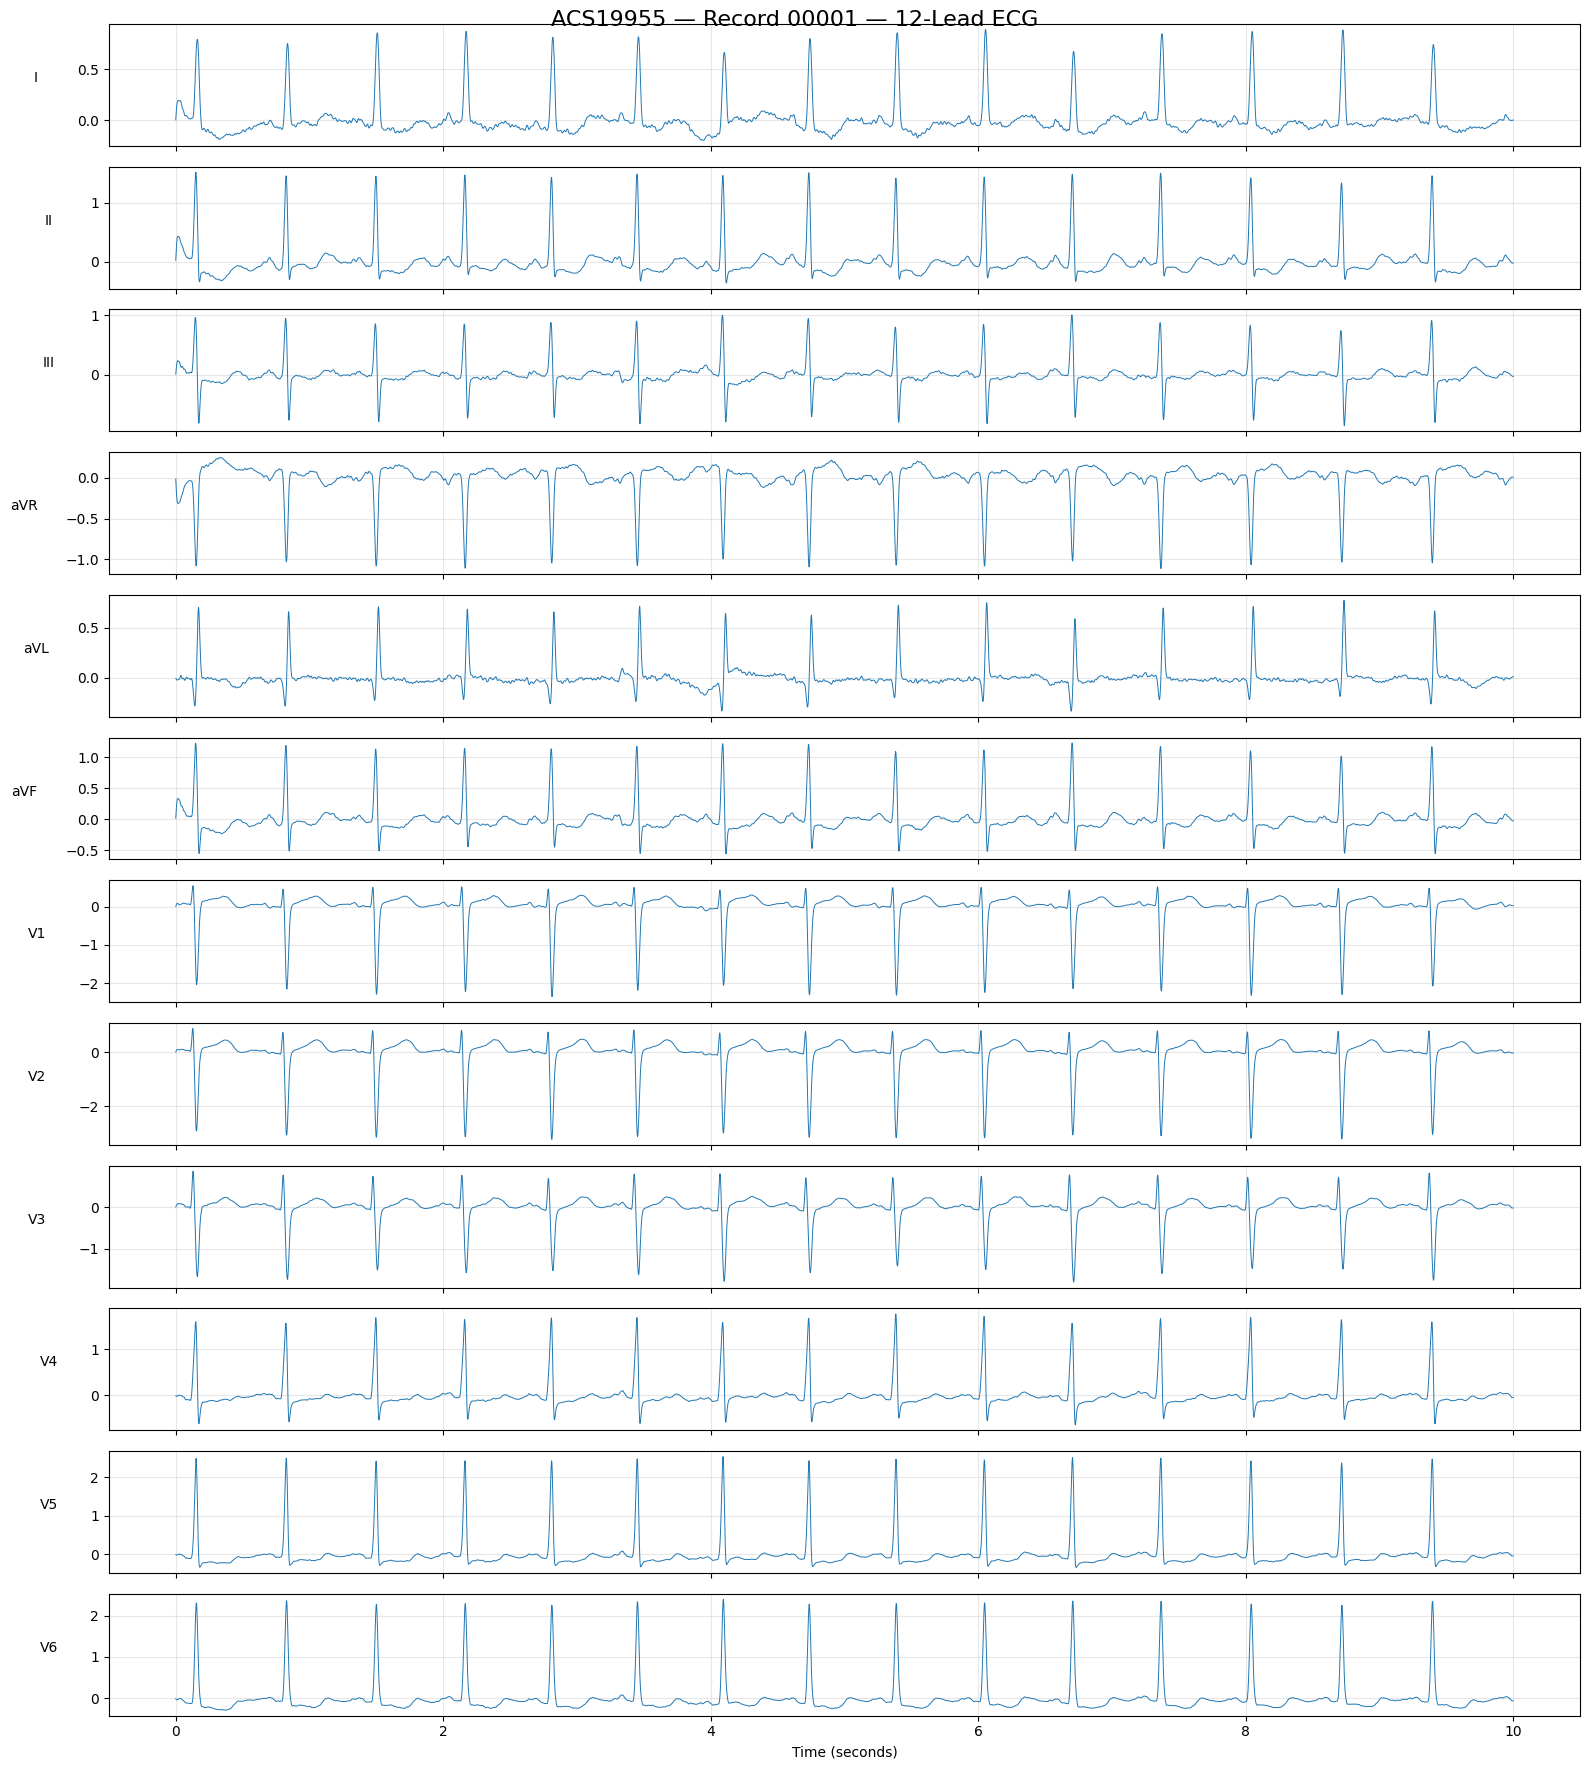


STEP 2 COMPLETE
Verified waveform decoding from .dat/.hea files.


In [11]:
# ============================================================
# STEP 2 — VERIFY ACS19955 ECG WAVEFORMS

# VERIFYING A SINGLE BEAT
# ============================================================
!pip install wfdb
import os
import zipfile
import tempfile
import numpy as np
import matplotlib.pyplot as plt
import wfdb

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

RAW_DIR = "/content/drive/MyDrive/ECG_Project/ACS19955/raw"

ROW_ZIP = os.path.join(
    RAW_DIR,
    "ECG_row_data.zip"
)

print("Raw dataset directory:")
print(RAW_DIR)

print("\nRow-data ZIP:")
print(ROW_ZIP)

assert os.path.exists(ROW_ZIP), "ECG_row_data.zip not found!"

# ------------------------------------------------------------
# 2. SELECT ECG RECORDS
# ------------------------------------------------------------

# We will verify 5 different recordings.
RECORD_IDS = [
    "00001",
    "00002",
    "00003",
    "00004",
    "00005"
]

# ------------------------------------------------------------
# 3. READ RECORDS DIRECTLY FROM ZIP
# ------------------------------------------------------------

results = []

with zipfile.ZipFile(ROW_ZIP, "r") as z:

    members = set(z.namelist())

    for record_id in RECORD_IDS:

        hea_name = f"row_data/{record_id}.hea"
        dat_name = f"row_data/{record_id}.dat"

        assert hea_name in members, f"Missing: {hea_name}"
        assert dat_name in members, f"Missing: {dat_name}"

        # Temporary directory for WFDB
        with tempfile.TemporaryDirectory() as tmpdir:

            hea_path = os.path.join(
                tmpdir,
                f"{record_id}.hea"
            )

            dat_path = os.path.join(
                tmpdir,
                f"{record_id}.dat"
            )

            # Extract only this ECG
            with open(hea_path, "wb") as f:
                f.write(z.read(hea_name))

            with open(dat_path, "wb") as f:
                f.write(z.read(dat_name))

            # ------------------------------------------------
            # Read ECG using WFDB
            # ------------------------------------------------

            record = wfdb.rdrecord(
                os.path.join(tmpdir, record_id)
            )

            signal = record.p_signal

            fs = record.fs
            n_samples = record.sig_len
            n_leads = record.n_sig
            lead_names = record.sig_name

            duration = n_samples / fs

            results.append({
                "record": record_id,
                "shape": signal.shape,
                "sampling_rate": fs,
                "samples": n_samples,
                "leads": n_leads,
                "duration": duration,
                "lead_names": lead_names,
                "min": np.min(signal),
                "max": np.max(signal),
                "mean": np.mean(signal),
                "std": np.std(signal)
            })

# ------------------------------------------------------------
# 4. PRINT VERIFICATION RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ACS19955 WAVEFORM VERIFICATION")
print("=" * 70)

for r in results:

    print(f"\nRecord: {r['record']}")

    print(f"Shape          : {r['shape']}")
    print(f"Sampling rate  : {r['sampling_rate']} Hz")
    print(f"Samples        : {r['samples']}")
    print(f"Number of leads: {r['leads']}")
    print(f"Duration       : {r['duration']:.2f} seconds")

    print(f"Lead names     : {r['lead_names']}")

    print(f"Minimum value  : {r['min']:.4f}")
    print(f"Maximum value  : {r['max']:.4f}")
    print(f"Mean           : {r['mean']:.4f}")
    print(f"Std            : {r['std']:.4f}")

# ------------------------------------------------------------
# 5. AUTOMATIC STRUCTURAL CHECKS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STRUCTURAL CHECKS")
print("=" * 70)

all_passed = True

for r in results:

    checks = {
        "12 leads": r["leads"] == 12,
        "500 Hz": r["sampling_rate"] == 500,
        "5000 samples": r["samples"] == 5000,
        "10 seconds": np.isclose(r["duration"], 10.0)
    }

    print(f"\nRecord {r['record']}")

    for name, passed in checks.items():

        status = "PASS" if passed else "FAIL"

        print(f"  {name:20s}: {status}")

        if not passed:
            all_passed = False

print("\n" + "=" * 70)

if all_passed:
    print("ALL WAVEFORM STRUCTURE CHECKS PASSED")
else:
    print("WARNING: ONE OR MORE CHECKS FAILED")

print("=" * 70)

# ------------------------------------------------------------
# 6. PLOT ONE COMPLETE 12-LEAD ECG
# ------------------------------------------------------------

# Re-read first ECG for visualization

with zipfile.ZipFile(ROW_ZIP, "r") as z:

    record_id = RECORD_IDS[0]

    with tempfile.TemporaryDirectory() as tmpdir:

        hea_path = os.path.join(
            tmpdir,
            f"{record_id}.hea"
        )

        dat_path = os.path.join(
            tmpdir,
            f"{record_id}.dat"
        )

        with open(hea_path, "wb") as f:
            f.write(
                z.read(
                    f"row_data/{record_id}.hea"
                )
            )

        with open(dat_path, "wb") as f:
            f.write(
                z.read(
                    f"row_data/{record_id}.dat"
                )
            )

        record = wfdb.rdrecord(
            os.path.join(tmpdir, record_id)
        )

        signal = record.p_signal
        fs = record.fs
        lead_names = record.sig_name

# Time axis
time = np.arange(signal.shape[0]) / fs

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    12,
    1,
    figsize=(16, 18),
    sharex=True
)

for i, ax in enumerate(axes):

    ax.plot(
        time,
        signal[:, i],
        linewidth=0.7
    )

    ax.set_ylabel(
        lead_names[i],
        rotation=0,
        labelpad=30
    )

    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")

fig.suptitle(
    f"ACS19955 — Record {RECORD_IDS[0]} — 12-Lead ECG",
    fontsize=16
)

plt.tight_layout()
plt.show()

print("\nSTEP 2 COMPLETE")
print("Verified waveform decoding from .dat/.hea files.")

In [12]:
#Metadata ↔ ECG mapping + labels

# ============================================================
# STEP 3 — ACS19955 METADATA ↔ WAVEFORM ↔ LABEL AUDIT
# ============================================================

import os
import zipfile
import pandas as pd
import numpy as np

# ============================================================
# 1. PATHS
# ============================================================

RAW_DIR = "/content/drive/MyDrive/ECG_Project/ACS19955/raw"

CSV_ZIP = os.path.join(RAW_DIR, "CSV.zip")
ROW_ZIP = os.path.join(RAW_DIR, "ECG_row_data.zip")
MED_ZIP = os.path.join(RAW_DIR, "ECG_median_data.zip")

assert os.path.exists(CSV_ZIP), "CSV.zip not found"
assert os.path.exists(ROW_ZIP), "ECG_row_data.zip not found"
assert os.path.exists(MED_ZIP), "ECG_median_data.zip not found"

# ============================================================
# 2. READ TRAIN / TEST CSV DIRECTLY FROM ZIP
# ============================================================

with zipfile.ZipFile(CSV_ZIP, "r") as z:

    train_csv = [x for x in z.namelist() if x.endswith("train.csv")][0]
    test_csv  = [x for x in z.namelist() if x.endswith("test.csv")][0]

    with z.open(train_csv) as f:
        train_df = pd.read_csv(f)

    with z.open(test_csv) as f:
        test_df = pd.read_csv(f)

print("=" * 70)
print("STEP 3 — METADATA ↔ WAVEFORM AUDIT")
print("=" * 70)

print("\nTrain shape:", train_df.shape)
print("Test shape :", test_df.shape)

# ============================================================
# 3. LABEL COLUMNS
# ============================================================

META_COLUMNS = [
    "Patient_id",
    "ecg_row_record",
    "ecg_med_record",
    "gender",
    "age",
    "Time_Interval"
]

LABEL_COLUMNS = [
    c for c in train_df.columns
    if c not in META_COLUMNS
]

print("\nNumber of labels:", len(LABEL_COLUMNS))
print("Labels:")
print(LABEL_COLUMNS)

# ============================================================
# 4. CHECK RECORD ID FORMAT
# ============================================================

def clean_record_id(x):
    """
    Converts values such as:

        04904.dat → 04904
        15878.med → 15878

    into a common numeric string representation.
    """
    x = str(x)

    if "." in x:
        x = x.split(".")[0]

    return x.zfill(5)


train_row_ids = set(
    train_df["ecg_row_record"]
    .map(clean_record_id)
)

train_med_ids = set(
    train_df["ecg_med_record"]
    .map(clean_record_id)
)

test_row_ids = set(
    test_df["ecg_row_record"]
    .map(clean_record_id)
)

test_med_ids = set(
    test_df["ecg_med_record"]
    .map(clean_record_id)
)

# ============================================================
# 5. GET ACTUAL RECORDS FROM ZIP FILES
# ============================================================

with zipfile.ZipFile(ROW_ZIP, "r") as z:

    row_dat_ids = {
        os.path.basename(x).split(".")[0]
        for x in z.namelist()
        if x.startswith("row_data/")
        and x.endswith(".dat")
    }

    row_hea_ids = {
        os.path.basename(x).split(".")[0]
        for x in z.namelist()
        if x.startswith("row_data/")
        and x.endswith(".hea")
    }

with zipfile.ZipFile(MED_ZIP, "r") as z:

    med_ids = {
        os.path.basename(x).split(".")[0]
        for x in z.namelist()
        if x.startswith("med_data/")
        and x.endswith(".med")
    }

# ============================================================
# 6. TRAIN MAPPING CHECK
# ============================================================

print("\n" + "=" * 70)
print("TRAIN ↔ WAVEFORM MAPPING")
print("=" * 70)

missing_dat = train_row_ids - row_dat_ids
missing_hea = train_row_ids - row_hea_ids
missing_med = train_med_ids - med_ids

print("\nTrain ECG records:", len(train_row_ids))

print(
    "Missing .dat files:",
    len(missing_dat)
)

print(
    "Missing .hea files:",
    len(missing_hea)
)

print(
    "Missing .med files:",
    len(missing_med)
)

# ============================================================
# 7. TEST MAPPING CHECK
# ============================================================

print("\n" + "=" * 70)
print("TEST ↔ WAVEFORM MAPPING")
print("=" * 70)

test_missing_dat = test_row_ids - row_dat_ids
test_missing_hea = test_row_ids - row_hea_ids
test_missing_med = test_med_ids - med_ids

print("\nTest ECG records:", len(test_row_ids))

print(
    "Missing .dat files:",
    len(test_missing_dat)
)

print(
    "Missing .hea files:",
    len(test_missing_hea)
)

print(
    "Missing .med files:",
    len(test_missing_med)
)

# ============================================================
# 8. CHECK ROW ↔ MED RECORD RELATIONSHIP
# ============================================================

print("\n" + "=" * 70)
print("ROW ↔ MED RECORD RELATIONSHIP")
print("=" * 70)

train_row_med_match = (
    train_df["ecg_row_record"]
    .map(clean_record_id)
    ==
    train_df["ecg_med_record"]
    .map(clean_record_id)
)

test_row_med_match = (
    test_df["ecg_row_record"]
    .map(clean_record_id)
    ==
    test_df["ecg_med_record"]
    .map(clean_record_id)
)

print(
    "\nTrain matching records:",
    train_row_med_match.sum(),
    "/",
    len(train_df)
)

print(
    "Train mismatches:",
    (~train_row_med_match).sum()
)

print(
    "\nTest matching records:",
    test_row_med_match.sum(),
    "/",
    len(test_df)
)

print(
    "Test mismatches:",
    (~test_row_med_match).sum()
)

# ============================================================
# 9. PATIENT-LEVEL LEAKAGE CHECK
# ============================================================

print("\n" + "=" * 70)
print("PATIENT SPLIT CHECK")
print("=" * 70)

train_patients = set(train_df["Patient_id"])
test_patients = set(test_df["Patient_id"])

patient_overlap = train_patients & test_patients

print("\nTrain patients:", len(train_patients))
print("Test patients :", len(test_patients))
print("Overlap       :", len(patient_overlap))

if len(patient_overlap) == 0:
    print("✓ NO PATIENT LEAKAGE DETECTED")
else:
    print("⚠ PATIENT OVERLAP DETECTED")

# ============================================================
# 10. RECORD OVERLAP CHECK
# ============================================================

print("\n" + "=" * 70)
print("RECORD SPLIT CHECK")
print("=" * 70)

row_overlap = train_row_ids & test_row_ids
med_overlap = train_med_ids & test_med_ids

print("\n.dat record overlap:", len(row_overlap))
print(".med record overlap:", len(med_overlap))

# ============================================================
# 11. LABEL VALUE AUDIT
# ============================================================

print("\n" + "=" * 70)
print("LABEL VALUE AUDIT")
print("=" * 70)

for label in LABEL_COLUMNS:

    values = sorted(
        train_df[label].dropna().unique().tolist()
    )

    print(
        f"{label:12s} : {values}"
    )

# ============================================================
# 12. LABEL COUNTS
# ============================================================

print("\n" + "=" * 70)
print("LABEL DISTRIBUTION")
print("=" * 70)

for label in LABEL_COLUMNS:

    counts = train_df[label].value_counts().sort_index()

    print(f"\n{label}")
    print(counts.to_dict())

# ============================================================
# 13. IMPORTANT CLINICAL RELATIONSHIPS
# ============================================================

print("\n" + "=" * 70)
print("CLINICAL LABEL RELATIONSHIPS")
print("=" * 70)

# ------------------------------------------------------------
# ACS subtype relationships
# ------------------------------------------------------------

acs_labels = ["STEMI", "NSTEMI", "UA"]

print("\nACS subtype combinations:")
print(
    train_df[acs_labels]
    .value_counts()
    .sort_index()
)

# Number of records with multiple ACS subtype labels
acs_sum = train_df[acs_labels].sum(axis=1)

print(
    "\nACS subtype label count per ECG:"
)

print(
    acs_sum.value_counts().sort_index().to_dict()
)

# ------------------------------------------------------------
# OMI vs ACS subtype
# ------------------------------------------------------------

print("\nOMI vs ACS subtype:")

print(
    pd.crosstab(
        train_df["OMI"],
        [
            train_df["STEMI"],
            train_df["NSTEMI"],
            train_df["UA"]
        ]
    )
)

# ------------------------------------------------------------
# CTO vs OMI
# ------------------------------------------------------------

print("\nCTO vs OMI:")

print(
    pd.crosstab(
        train_df["CTO"],
        train_df["OMI"]
    )
)

# ============================================================
# 14. VESSEL LABEL AUDIT
# ============================================================

VESSEL_LABELS = [
    "LM",
    "PLAD",
    "MLAD",
    "DLAD",
    "DB",
    "PLCX",
    "MLCX",
    "DLCX",
    "OM",
    "PRCA",
    "MRCA",
    "DRCA"
]

print("\n" + "=" * 70)
print("VESSEL LABEL ANALYSIS")
print("=" * 70)

print("\nVessel labels and possible values:")

for label in VESSEL_LABELS:

    values = sorted(
        train_df[label].unique().tolist()
    )

    print(
        f"{label:8s}: {values}"
    )

# ============================================================
# 15. VESSEL INVOLVEMENT
# ============================================================

# A vessel is considered involved if its value > 0.

vessel_binary = (
    train_df[VESSEL_LABELS] > 0
).astype(int)

vessel_count = vessel_binary.sum(axis=1)

print("\nNumber of involved vessel-segments per ECG:")

print(
    vessel_count.value_counts()
    .sort_index()
    .to_dict()
)

# ============================================================
# 16. OMI vs VESSEL INVOLVEMENT
# ============================================================

print("\nOMI vs number of involved vessel segments:")

print(
    pd.crosstab(
        train_df["OMI"],
        vessel_count
    )
)

# ============================================================
# 17. FINAL AUTOMATIC CHECK
# ============================================================

print("\n" + "=" * 70)
print("FINAL AUDIT SUMMARY")
print("=" * 70)

checks = {

    "Train .dat mapping":
        len(missing_dat) == 0,

    "Train .hea mapping":
        len(missing_hea) == 0,

    "Train .med mapping":
        len(missing_med) == 0,

    "Test .dat mapping":
        len(test_missing_dat) == 0,

    "Test .hea mapping":
        len(test_missing_hea) == 0,

    "Test .med mapping":
        len(test_missing_med) == 0,

    "Train row/med consistency":
        train_row_med_match.all(),

    "Test row/med consistency":
        test_row_med_match.all(),

    "No patient overlap":
        len(patient_overlap) == 0,

    "No row-record overlap":
        len(row_overlap) == 0,

    "No med-record overlap":
        len(med_overlap) == 0
}

for name, passed in checks.items():

    print(
        f"{'✓' if passed else '✗'} {name}"
    )

print("\n" + "=" * 70)
print("STEP 3 COMPLETE")
print("=" * 70)

STEP 3 — METADATA ↔ WAVEFORM AUDIT

Train shape: (17960, 28)
Test shape : (1995, 6)

Number of labels: 22
Labels:
['AMI', 'OMI', 'CTO', 'PCI', 'NSTEMI', 'STEMI', 'UA', 'LM', 'PLAD', 'MLAD', 'DLAD', 'DB', 'PLCX', 'MLCX', 'DLCX', 'OM', 'PRCA', 'MRCA', 'DRCA', 'VF_VT', 'Paced', 'Prior_PCI']

TRAIN ↔ WAVEFORM MAPPING

Train ECG records: 17960
Missing .dat files: 0
Missing .hea files: 0
Missing .med files: 0

TEST ↔ WAVEFORM MAPPING

Test ECG records: 1995
Missing .dat files: 0
Missing .hea files: 0
Missing .med files: 0

ROW ↔ MED RECORD RELATIONSHIP

Train matching records: 17960 / 17960
Train mismatches: 0

Test matching records: 1995 / 1995
Test mismatches: 0

PATIENT SPLIT CHECK

Train patients: 17018
Test patients : 1891
Overlap       : 0
✓ NO PATIENT LEAKAGE DETECTED

RECORD SPLIT CHECK

.dat record overlap: 0
.med record overlap: 0

LABEL VALUE AUDIT
AMI          : [0, 1]
OMI          : [0, 1]
CTO          : [0, 1]
PCI          : [0, 1]
NSTEMI       : [0, 1]
STEMI        : [0, 1]
UA

In [13]:
#THE TEST FOR NON INTERSECTION OF THE VALIDATION , TRAINING , TESTING DATAS

# ============================================================
# STEP 4 — PATIENT-SAFE TRAIN / VALIDATION SPLIT
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/ECG_Project"
RAW_DIR = os.path.join(PROJECT_DIR, "ACS19955", "raw")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

TRAIN_CSV = os.path.join(RAW_DIR, "CSV", "train.csv")
TEST_CSV = os.path.join(RAW_DIR, "CSV", "test.csv")

SPLIT_DIR = os.path.join(RESULTS_DIR, "dataset_split")
os.makedirs(SPLIT_DIR, exist_ok=True)

# ============================================================
# LOAD TRAIN / TEST METADATA DIRECTLY FROM CSV.zip
# ============================================================

import os
import zipfile
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/ECG_Project"
RAW_DIR = os.path.join(PROJECT_DIR, "ACS19955", "raw")

CSV_ZIP = os.path.join(RAW_DIR, "CSV.zip")

with zipfile.ZipFile(CSV_ZIP, "r") as z:

    train_df = pd.read_csv(
        z.open("CSV/train.csv")
    )

    test_df = pd.read_csv(
        z.open("CSV/test.csv")
    )

print("=" * 70)
print("METADATA LOADED")
print("=" * 70)

print("Train:", train_df.shape)
print("Test :", test_df.shape)

# ------------------------------------------------------------
# 3. VERIFY TEST SET IS NOT TOUCHED
# ------------------------------------------------------------

train_patients = set(train_df["Patient_id"])
test_patients = set(test_df["Patient_id"])

patient_overlap = train_patients.intersection(test_patients)

print("\nPatient leakage check:")
print(f"Train/Test overlapping patients: {len(patient_overlap)}")

if len(patient_overlap) != 0:
    raise RuntimeError(
        "Patient leakage detected between train and test!"
    )

print("✓ Official test set is patient-independent")

# ------------------------------------------------------------
# 4. PATIENT-LEVEL SPLIT
# ------------------------------------------------------------
#
# IMPORTANT:
# We split ECGs by Patient_id rather than individual ECGs.
#
# Therefore, if a patient has multiple ECGs:
#
#     ALL ECGs → TRAIN
#
# OR
#
#     ALL ECGs → VALIDATION
#
# Never both.
#
# ------------------------------------------------------------

VALIDATION_SIZE = 0.15
RANDOM_SEED = 42

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_SEED
)

train_indices, val_indices = next(
    splitter.split(
        train_df,
        groups=train_df["Patient_id"]
    )
)

train_split = train_df.iloc[train_indices].copy()
val_split = train_df.iloc[val_indices].copy()

# ------------------------------------------------------------
# 5. RESET INDICES
# ------------------------------------------------------------

train_split.reset_index(drop=True, inplace=True)
val_split.reset_index(drop=True, inplace=True)

# ------------------------------------------------------------
# 6. VERIFY PATIENT INDEPENDENCE
# ------------------------------------------------------------

train_patients = set(train_split["Patient_id"])
val_patients = set(val_split["Patient_id"])
test_patients = set(test_df["Patient_id"])

train_val_overlap = train_patients.intersection(val_patients)
train_test_overlap = train_patients.intersection(test_patients)
val_test_overlap = val_patients.intersection(test_patients)

print("\n" + "=" * 70)
print("PATIENT LEAKAGE VERIFICATION")
print("=" * 70)

print(f"Train ∩ Validation : {len(train_val_overlap)}")
print(f"Train ∩ Test       : {len(train_test_overlap)}")
print(f"Validation ∩ Test  : {len(val_test_overlap)}")

if (
    len(train_val_overlap) != 0
    or len(train_test_overlap) != 0
    or len(val_test_overlap) != 0
):
    raise RuntimeError(
        "Patient leakage detected!"
    )

print("\n✓ ZERO patient overlap across all three splits")

# ------------------------------------------------------------
# 7. VERIFY ECG RECORD INDEPENDENCE
# ------------------------------------------------------------

train_records = set(train_split["ecg_row_record"])
val_records = set(val_split["ecg_row_record"])
test_records = set(test_df["ecg_row_record"])

record_overlaps = {
    "Train ∩ Validation":
        len(train_records.intersection(val_records)),

    "Train ∩ Test":
        len(train_records.intersection(test_records)),

    "Validation ∩ Test":
        len(val_records.intersection(test_records))
}

print("\nECG record overlap:")

for name, count in record_overlaps.items():
    print(f"{name:22s}: {count}")

if any(record_overlaps.values()):
    raise RuntimeError(
        "ECG record overlap detected!"
    )

print("✓ ZERO ECG record overlap")

# ------------------------------------------------------------
# 8. DATASET SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL SPLIT")
print("=" * 70)

print(
    f"Train      : {len(train_split):5d} ECGs | "
    f"{len(train_patients):5d} patients"
)

print(
    f"Validation : {len(val_split):5d} ECGs | "
    f"{len(val_patients):5d} patients"
)

print(
    f"Test       : {len(test_df):5d} ECGs | "
    f"{len(test_patients):5d} patients"
)

total = len(train_split) + len(val_split) + len(test_df)

print(f"\nTotal      : {total:5d} ECGs")

# ------------------------------------------------------------
# 9. CHECK THAT ALL TRAINING ECGs ARE ACCOUNTED FOR
# ------------------------------------------------------------

if len(train_split) + len(val_split) != len(train_df):
    raise RuntimeError(
        "Train + validation does not equal original training set!"
    )

print("✓ All original training ECGs accounted for")

# ------------------------------------------------------------
# 10. SAVE SPLITS
# ------------------------------------------------------------

TRAIN_SPLIT_PATH = os.path.join(
    SPLIT_DIR,
    "train_split.csv"
)

VAL_SPLIT_PATH = os.path.join(
    SPLIT_DIR,
    "validation_split.csv"
)

TEST_SPLIT_PATH = os.path.join(
    SPLIT_DIR,
    "test_split.csv"
)

train_split.to_csv(
    TRAIN_SPLIT_PATH,
    index=False
)

val_split.to_csv(
    VAL_SPLIT_PATH,
    index=False
)

test_df.to_csv(
    TEST_SPLIT_PATH,
    index=False
)

# ------------------------------------------------------------
# 11. SAVE SPLIT INFORMATION
# ------------------------------------------------------------

split_info = {
    "random_seed": RANDOM_SEED,
    "validation_fraction": VALIDATION_SIZE,
    "train_ecgs": len(train_split),
    "validation_ecgs": len(val_split),
    "test_ecgs": len(test_df),
    "train_patients": len(train_patients),
    "validation_patients": len(val_patients),
    "test_patients": len(test_patients),
    "patient_leakage": False,
    "record_leakage": False
}

split_info_path = os.path.join(
    SPLIT_DIR,
    "split_info.txt"
)

with open(split_info_path, "w") as f:
    for key, value in split_info.items():
        f.write(f"{key}: {value}\n")

# ------------------------------------------------------------
# 12. FINAL MESSAGE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 4 COMPLETE ✓")
print("=" * 70)

print("\nSaved files:")

print(TRAIN_SPLIT_PATH)
print(VAL_SPLIT_PATH)
print(TEST_SPLIT_PATH)
print(split_info_path)

print("\nThese splits are now FIXED.")
print("Do not regenerate them for individual experiments.")

METADATA LOADED
Train: (17960, 28)
Test : (1995, 6)

Patient leakage check:
Train/Test overlapping patients: 0
✓ Official test set is patient-independent

PATIENT LEAKAGE VERIFICATION
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0

✓ ZERO patient overlap across all three splits

ECG record overlap:
Train ∩ Validation    : 0
Train ∩ Test          : 0
Validation ∩ Test     : 0
✓ ZERO ECG record overlap

FINAL SPLIT
Train      : 15275 ECGs | 14465 patients
Validation :  2685 ECGs |  2553 patients
Test       :  1995 ECGs |  1891 patients

Total      : 19955 ECGs
✓ All original training ECGs accounted for

STEP 4 COMPLETE ✓

Saved files:
/content/drive/MyDrive/ECG_Project/results/dataset_split/train_split.csv
/content/drive/MyDrive/ECG_Project/results/dataset_split/validation_split.csv
/content/drive/MyDrive/ECG_Project/results/dataset_split/test_split.csv
/content/drive/MyDrive/ECG_Project/results/dataset_split/split_info.txt

These splits are now FIXED.
Do not regene

In [14]:
#ACTUAL VALIDATION AND PREPROCESSING STEPS


In [15]:
# ============================================================
# STEP 5.1 — ECG SIGNAL VALIDATION
# ============================================================

import os
import numpy as np
import pandas as pd
import wfdb

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/ECG_Project"

RAW_DIR = os.path.join(
    PROJECT_DIR,
    "ACS19955",
    "raw"
)

ROW_ZIP = os.path.join(
    RAW_DIR,
    "ECG_row_data.zip"
)

# We will temporarily extract ONLY a few records for inspection.
VALIDATION_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "preprocessing",
    "validation_samples"
)

os.makedirs(VALIDATION_DIR, exist_ok=True)

# ------------------------------------------------------------
# IMPORTANT
# ------------------------------------------------------------
# We need actual .dat/.hea files available to wfdb.
# Extract only a small number of records from the ZIP.
# The original ZIP remains untouched.
# ------------------------------------------------------------

import zipfile

SAMPLE_RECORDS = [
    "00001",
    "00002",
    "00003",
    "00100",
    "01000"
]

with zipfile.ZipFile(ROW_ZIP, "r") as z:

    members = z.namelist()

    for record_id in SAMPLE_RECORDS:

        dat_name = f"row_data/{record_id}.dat"
        hea_name = f"row_data/{record_id}.hea"

        for filename in [dat_name, hea_name]:

            if filename in members:
                z.extract(
                    filename,
                    VALIDATION_DIR
                )

# ------------------------------------------------------------
# WFDB RECORD DIRECTORY
# ------------------------------------------------------------

WFDB_DIR = os.path.join(
    VALIDATION_DIR,
    "row_data"
)

# ------------------------------------------------------------
# VALIDATE RECORDS
# ------------------------------------------------------------

validation_results = []

print("=" * 70)
print("STEP 5.1 — ECG SIGNAL VALIDATION")
print("=" * 70)

for record_id in SAMPLE_RECORDS:

    record_path = os.path.join(
        WFDB_DIR,
        record_id
    )

    try:

        # ----------------------------------------------------
        # Read WFDB ECG
        # ----------------------------------------------------

        record = wfdb.rdrecord(record_path)

        signal = record.p_signal

        # ----------------------------------------------------
        # Basic properties
        # ----------------------------------------------------

        n_samples = signal.shape[0]
        n_leads = signal.shape[1]

        sampling_frequency = record.fs

        duration = (
            n_samples / sampling_frequency
        )

        # ----------------------------------------------------
        # Numerical checks
        # ----------------------------------------------------

        has_nan = np.isnan(signal).any()
        has_inf = np.isinf(signal).any()

        min_value = np.min(signal)
        max_value = np.max(signal)

        mean_value = np.mean(signal)
        std_value = np.std(signal)

        # ----------------------------------------------------
        # Lead names
        # ----------------------------------------------------

        lead_names = record.sig_name

        # ----------------------------------------------------
        # Validation flags
        # ----------------------------------------------------

        shape_ok = (
            n_leads == 12
            and n_samples == 5000
        )

        fs_ok = (
            sampling_frequency == 500
        )

        numerical_ok = (
            not has_nan
            and not has_inf
        )

        valid = (
            shape_ok
            and fs_ok
            and numerical_ok
        )

        # ----------------------------------------------------
        # Store results
        # ----------------------------------------------------

        validation_results.append({

            "record": record_id,

            "leads": n_leads,

            "samples": n_samples,

            "sampling_frequency": sampling_frequency,

            "duration_seconds": duration,

            "has_nan": has_nan,

            "has_inf": has_inf,

            "min_amplitude": min_value,

            "max_amplitude": max_value,

            "mean": mean_value,

            "std": std_value,

            "valid": valid
        })

        # ----------------------------------------------------
        # Display
        # ----------------------------------------------------

        print("\n" + "-" * 70)

        print(f"Record       : {record_id}")

        print(
            f"Shape        : "
            f"{signal.shape}"
        )

        print(
            f"Sampling     : "
            f"{sampling_frequency} Hz"
        )

        print(
            f"Duration     : "
            f"{duration:.3f} seconds"
        )

        print(
            f"Leads        : "
            f"{lead_names}"
        )

        print(
            f"NaN          : "
            f"{has_nan}"
        )

        print(
            f"Inf          : "
            f"{has_inf}"
        )

        print(
            f"Amplitude    : "
            f"{min_value:.4f} → {max_value:.4f}"
        )

        print(
            f"Mean         : "
            f"{mean_value:.6f}"
        )

        print(
            f"Std          : "
            f"{std_value:.6f}"
        )

        print(
            f"VALID        : "
            f"{'✓' if valid else '✗'}"
        )

    except Exception as e:

        print(
            f"\nRecord {record_id} FAILED:"
        )

        print(e)

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

validation_df = pd.DataFrame(
    validation_results
)

print("\n" + "=" * 70)
print("VALIDATION SUMMARY")
print("=" * 70)

if len(validation_df) > 0:

    print(
        f"Records checked : "
        f"{len(validation_df)}"
    )

    print(
        f"Valid records   : "
        f"{validation_df['valid'].sum()}"
    )

    print(
        f"Invalid records : "
        f"{(~validation_df['valid']).sum()}"
    )

    print(
        "\nShapes observed:"
    )

    print(
        validation_df[
            [
                "leads",
                "samples",
                "sampling_frequency"
            ]
        ].drop_duplicates()
    )

# ------------------------------------------------------------
# SAVE VALIDATION REPORT
# ------------------------------------------------------------

PREPROCESSING_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "preprocessing"
)

os.makedirs(
    PREPROCESSING_DIR,
    exist_ok=True
)

REPORT_PATH = os.path.join(
    PREPROCESSING_DIR,
    "signal_validation_report.csv"
)

validation_df.to_csv(
    REPORT_PATH,
    index=False
)

print(
    "\nValidation report saved:"
)

print(REPORT_PATH)

print("\n" + "=" * 70)
print("STEP 5.1 COMPLETE")
print("=" * 70)

STEP 5.1 — ECG SIGNAL VALIDATION

----------------------------------------------------------------------
Record       : 00001
Shape        : (5000, 12)
Sampling     : 500 Hz
Duration     : 10.000 seconds
Leads        : ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
NaN          : False
Inf          : False
Amplitude    : -3.2200 → 2.5360
Mean         : -0.000378
Std          : 0.324837
VALID        : ✓

----------------------------------------------------------------------
Record       : 00002
Shape        : (5000, 12)
Sampling     : 500 Hz
Duration     : 10.000 seconds
Leads        : ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
NaN          : False
Inf          : False
Amplitude    : -2.4100 → 1.8420
Mean         : -0.000422
Std          : 0.223510
VALID        : ✓

----------------------------------------------------------------------
Record       : 00003
Shape        : (5000, 12)
Sampling     : 500 Hz
Duration     : 10.000 


RECORD: 00001
Shape: (5000, 12)
Sampling frequency: 500
Leads: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


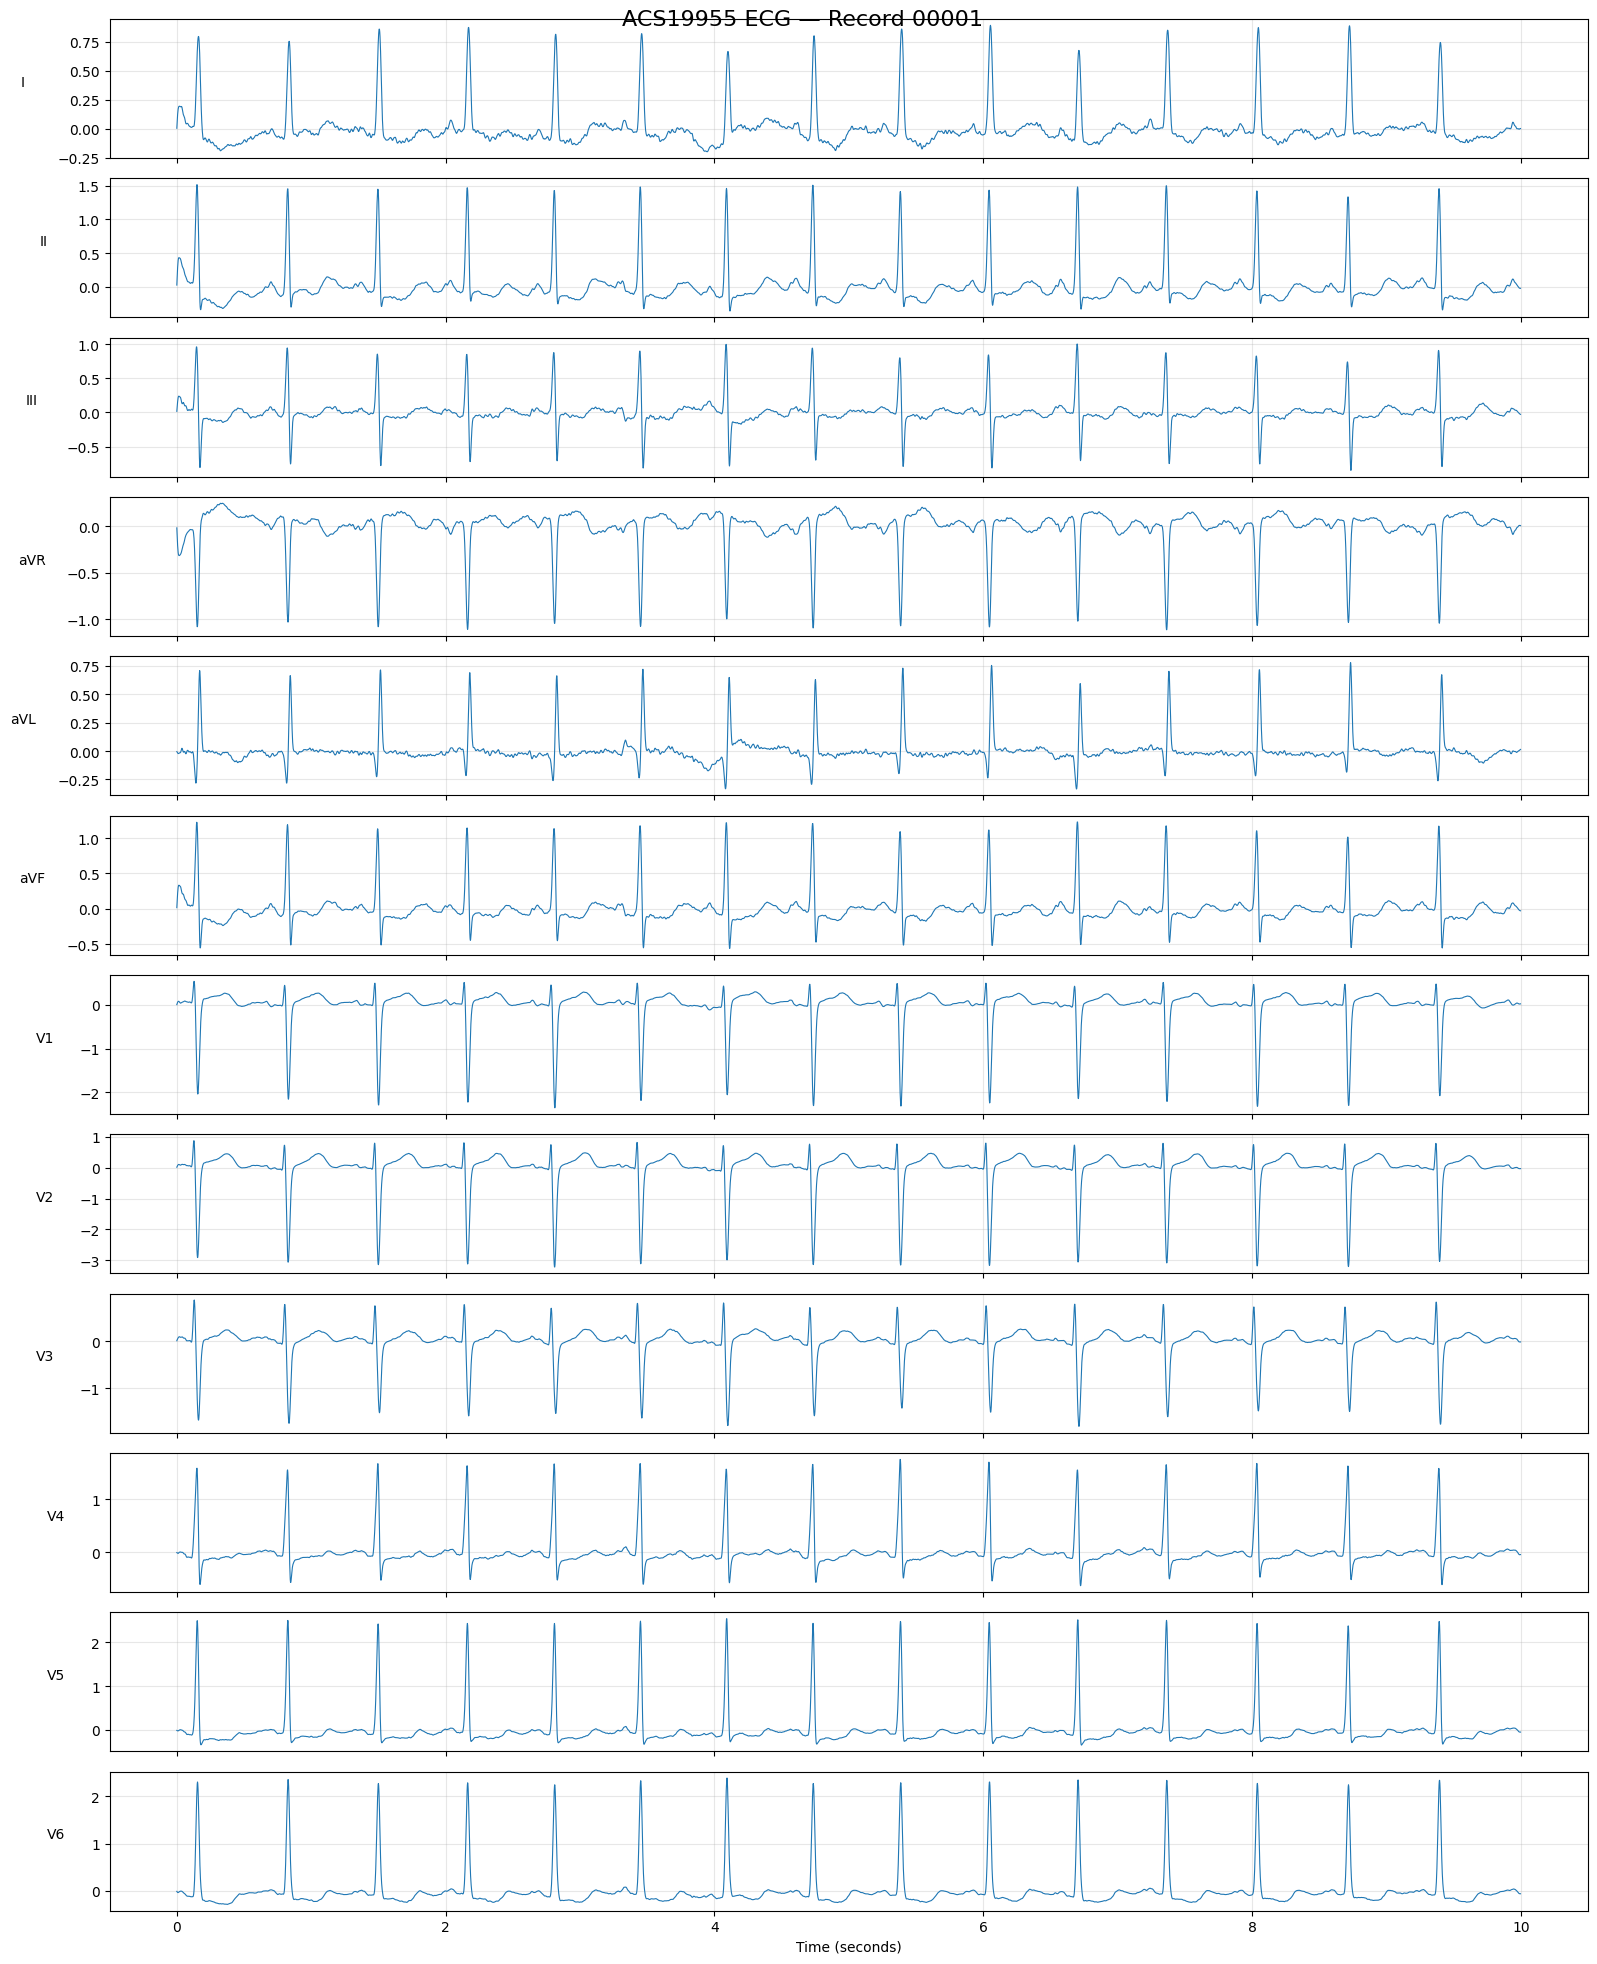


RECORD: 00002
Shape: (5000, 12)
Sampling frequency: 500
Leads: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


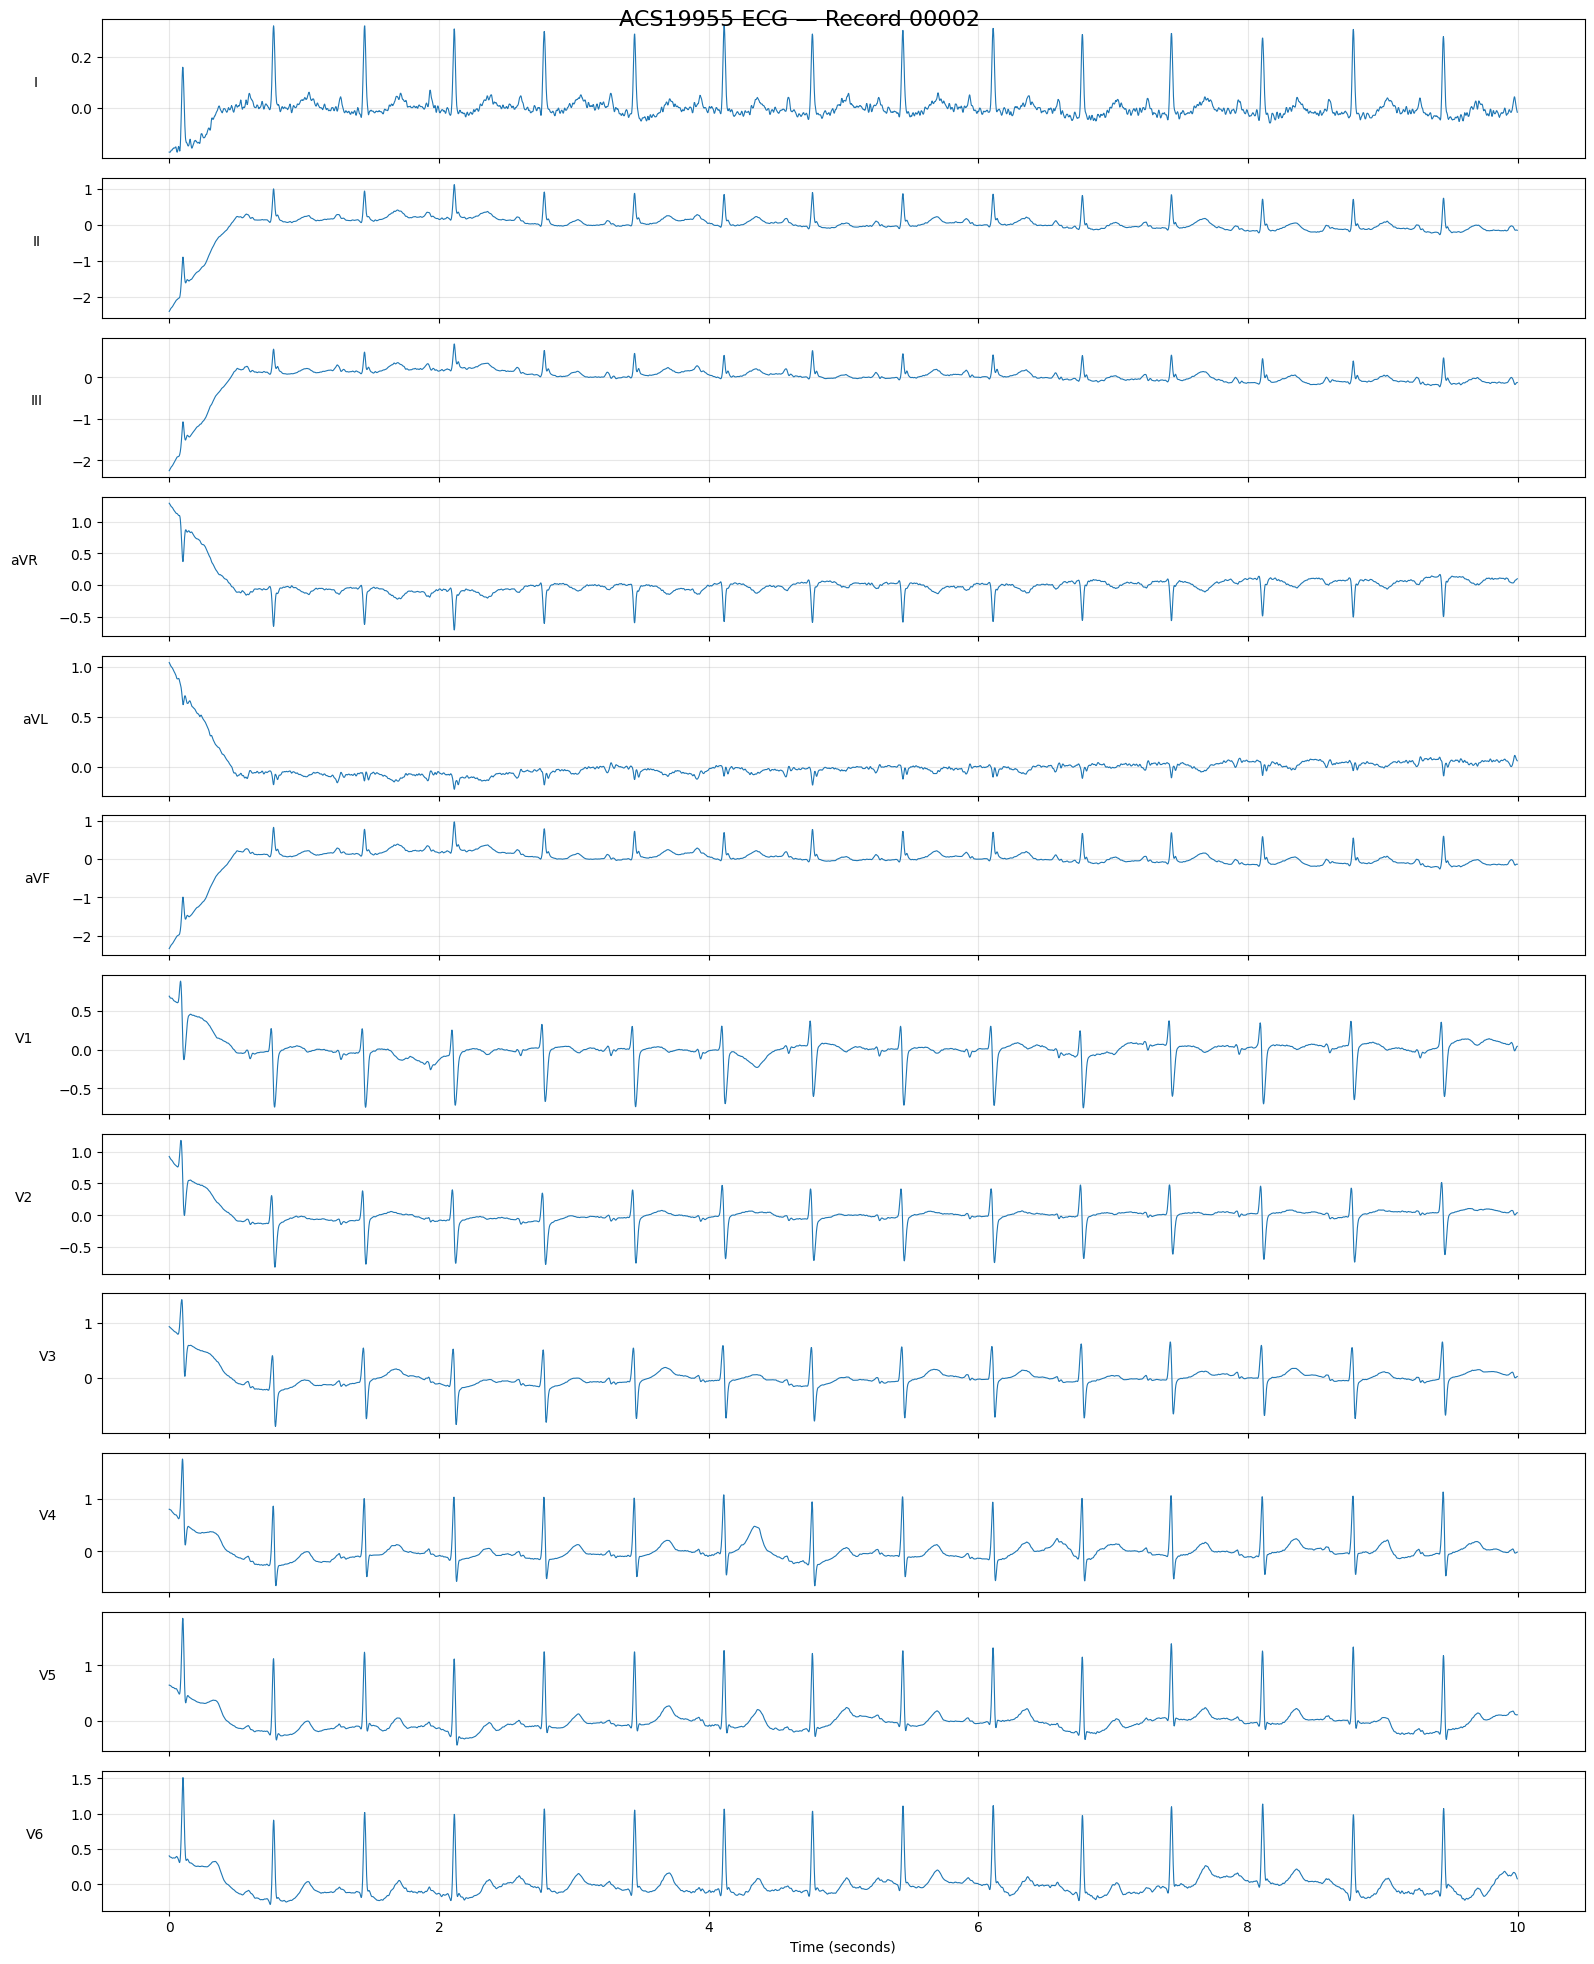


RECORD: 00003
Shape: (5000, 12)
Sampling frequency: 500
Leads: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


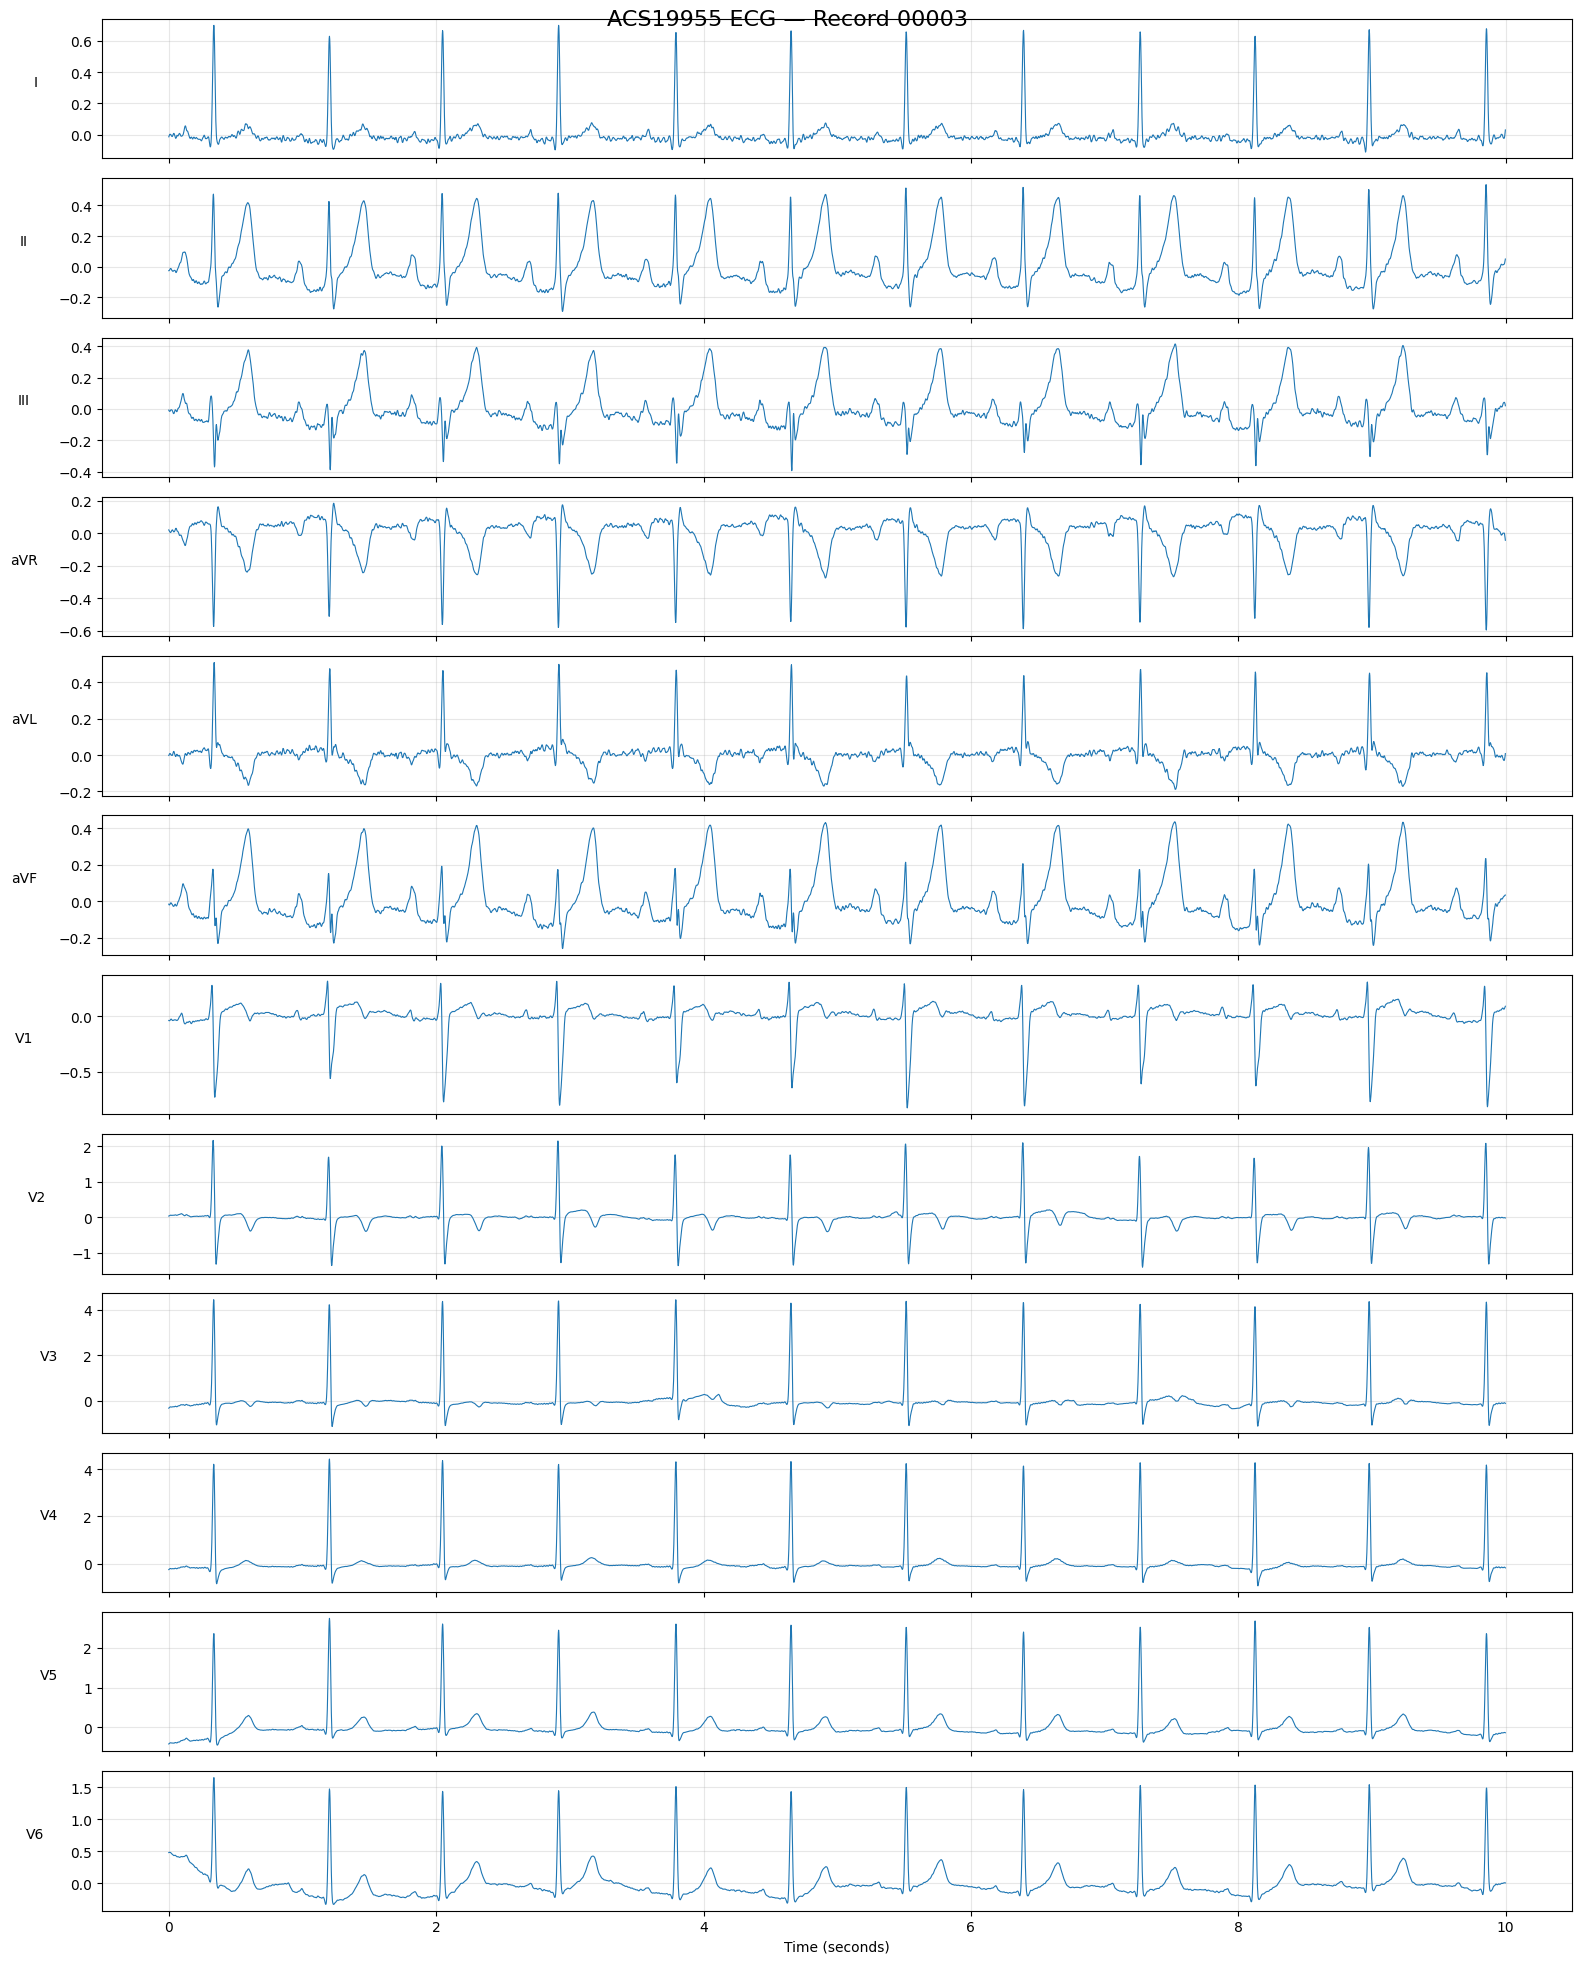


AMPLITUDE STATISTICS

Record 00001
I    | min= -0.1980 | max=  0.8920 | mean= -0.0001 | std=  0.1666
II   | min= -0.3620 | max=  1.5180 | mean= -0.0002 | std=  0.2666
III  | min= -0.8480 | max=  1.0020 | mean= -0.0003 | std=  0.1868
aVR  | min= -1.1120 | max=  0.2480 | mean= -0.0008 | std=  0.2015
aVL  | min= -0.3340 | max=  0.7760 | mean= -0.0001 | std=  0.1165
aVF  | min= -0.5560 | max=  1.2260 | mean= -0.0003 | std=  0.2144
V1   | min= -2.3560 | max=  0.5420 | mean= -0.0010 | std=  0.4049
V2   | min= -3.2200 | max=  0.8740 | mean= -0.0010 | std=  0.5815
V3   | min= -1.8040 | max=  0.8660 | mean= -0.0009 | std=  0.3185
V4   | min= -0.6360 | max=  1.7600 | mean= -0.0000 | std=  0.2909
V5   | min= -0.3460 | max=  2.5360 | mean=  0.0001 | std=  0.4169
V6   | min= -0.2900 | max=  2.3920 | mean=  0.0002 | std=  0.4128

Record 00002
I    | min= -0.1740 | max=  0.3220 | mean= -0.0003 | std=  0.0538
II   | min= -2.4100 | max=  1.1160 | mean= -0.0006 | std=  0.3346
III  | min= -2.2520 | max=

In [16]:
# ============================================================
# STEP 5.2 — VISUAL ECG WAVEFORM INSPECTION
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import wfdb

# ------------------------------------------------------------
# PATH
# ------------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/ECG_Project"

WFDB_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "preprocessing",
    "validation_samples",
    "row_data"
)

# ------------------------------------------------------------
# RECORDS TO INSPECT
# ------------------------------------------------------------

RECORDS = ["00001", "00002", "00003"]

# Standard 12-lead order
STANDARD_LEADS = [
    "I", "II", "III",
    "aVR", "aVL", "aVF",
    "V1", "V2", "V3",
    "V4", "V5", "V6"
]

# ------------------------------------------------------------
# 1. PLOT ALL 12 LEADS FOR EACH RECORD
# ------------------------------------------------------------

for record_id in RECORDS:

    record_path = os.path.join(
        WFDB_DIR,
        record_id
    )

    record = wfdb.rdrecord(record_path)

    signal = record.p_signal
    fs = record.fs
    lead_names = record.sig_name

    time = np.arange(signal.shape[0]) / fs

    print("\n" + "=" * 70)
    print(f"RECORD: {record_id}")
    print("=" * 70)

    print("Shape:", signal.shape)
    print("Sampling frequency:", fs)
    print("Leads:", lead_names)

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        12,
        1,
        figsize=(16, 20),
        sharex=True
    )

    for i, ax in enumerate(axes):

        ax.plot(
            time,
            signal[:, i],
            linewidth=0.8
        )

        ax.set_ylabel(
            lead_names[i],
            rotation=0,
            labelpad=25
        )

        ax.grid(
            True,
            alpha=0.3
        )

    axes[-1].set_xlabel(
        "Time (seconds)"
    )

    fig.suptitle(
        f"ACS19955 ECG — Record {record_id}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 2. AMPLITUDE STATISTICS FOR ALL INSPECTED RECORDS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("AMPLITUDE STATISTICS")
print("=" * 70)

for record_id in RECORDS:

    record = wfdb.rdrecord(
        os.path.join(WFDB_DIR, record_id)
    )

    signal = record.p_signal

    print(f"\nRecord {record_id}")

    for i, lead in enumerate(record.sig_name):

        lead_signal = signal[:, i]

        print(
            f"{lead:4s} | "
            f"min={lead_signal.min():8.4f} | "
            f"max={lead_signal.max():8.4f} | "
            f"mean={lead_signal.mean():8.4f} | "
            f"std={lead_signal.std():8.4f}"
        )

# ------------------------------------------------------------
# 3. CHECK LEAD ORDER
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("LEAD ORDER CHECK")
print("=" * 70)

for record_id in RECORDS:

    record = wfdb.rdrecord(
        os.path.join(WFDB_DIR, record_id)
    )

    print(
        f"{record_id}: "
        f"{record.sig_name}"
    )

THE ULTIMATE PREPROCESSING

In [17]:
# PRE PROCESSING PIPELINE

# WFDB decoding
#       ↓
# 12-lead verification
#       ↓
# 500 Hz / 5000 samples
#       ↓
# 0.5 Hz high-pass
#       ↓
# 50 Hz low-pass
#       ↓
# 50 Hz notch
#       ↓
# segment-level Z-score
#       ↓
# (12, 5000) float32

Setup + extract row data locally

In [27]:
### CELL 1 — Setup and Load Fixed Splits


# ============================================================
# STEP 5.4 — FINAL ECG PREPROCESSING
# CELL 1: SETUP + LOAD FIXED SPLITS
# ============================================================

import os
import zipfile
import numpy as np
import pandas as pd
import wfdb
import h5py

from scipy.signal import butter, filtfilt, iirnotch
from tqdm.auto import tqdm


# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/ECG_Project"

RAW_DIR = os.path.join(
    PROJECT_DIR, "ACS19955", "raw"
)

SPLIT_DIR = os.path.join(
    PROJECT_DIR, "results", "dataset_split"
)

PROCESSED_DIR = os.path.join(
    PROJECT_DIR, "results", "preprocessing", "processed"
)

ROW_ZIP = os.path.join(
    RAW_DIR, "ECG_row_data.zip"
)

LOCAL_ROW_DIR = "/content/ACS19955_row_data"

os.makedirs(
    PROCESSED_DIR,
    exist_ok=True
)


# ============================================================
# FIXED DATA SPLITS
# ============================================================

train_df = pd.read_csv(
    os.path.join(SPLIT_DIR, "train_split.csv")
)

val_df = pd.read_csv(
    os.path.join(SPLIT_DIR, "validation_split.csv")
)

test_df = pd.read_csv(
    os.path.join(SPLIT_DIR, "test_split.csv")
)

print("=" * 70)
print("STEP 5.4 — FINAL ECG PREPROCESSING")
print("=" * 70)

print("\nFixed splits:")
print(f"Train      : {len(train_df)}")
print(f"Validation : {len(val_df)}")
print(f"Test       : {len(test_df)}")


# ============================================================
# EXTRACT ROW DATA LOCALLY
# ============================================================

if not os.path.exists(LOCAL_ROW_DIR):

    print("\nExtracting ECG row data locally...")

    with zipfile.ZipFile(ROW_ZIP, "r") as z:
        z.extractall(LOCAL_ROW_DIR)

    print("Extraction complete.")

else:
    print("\nLocal row-data already exists.")


# ============================================================
# LOCATE WFDB DIRECTORY
# ============================================================

ROW_DATA_DIR = os.path.join(
    LOCAL_ROW_DIR,
    "row_data"
)

if not os.path.isdir(ROW_DATA_DIR):

    raise FileNotFoundError(
        f"WFDB directory not found:\n{ROW_DATA_DIR}"
    )

print("\nWFDB directory:")
print(ROW_DATA_DIR)

print("\nCELL 1 COMPLETE ✓")


STEP 5.4 — FINAL ECG PREPROCESSING

Fixed splits:
Train      : 15275
Validation : 2685
Test       : 1995

Local row-data already exists.

WFDB directory:
/content/ACS19955_row_data/row_data

CELL 1 COMPLETE ✓


Final preprocessing function

In [29]:
### CELL 2 — Final Preprocessing Function


# ============================================================
# CELL 2 — ECG PREPROCESSING FUNCTION
# ============================================================

FS = 500
EXPECTED_SAMPLES = 5000
NUM_LEADS = 12

STANDARD_LEADS = [
    "I", "II", "III",
    "aVR", "aVL", "aVF",
    "V1", "V2", "V3",
    "V4", "V5", "V6"
]


# ============================================================
# FILTER DESIGN
# ============================================================

# 0.5 Hz high-pass
B_HP, A_HP = butter(
    2, 0.5,
    btype="highpass",
    fs=FS
)

# 50 Hz low-pass
B_LP, A_LP = butter(
    2, 50,
    btype="lowpass",
    fs=FS
)

# 50 Hz notch
B_NOTCH, A_NOTCH = iirnotch(
    50,
    Q=30,
    fs=FS
)


# ============================================================
# REPAIR ISOLATED NON-FINITE VALUES
# ============================================================

def repair_signal(signal):

    signal = np.asarray(
        signal,
        dtype=np.float32
    )

    for lead in range(signal.shape[1]):

        x = signal[:, lead]
        bad = ~np.isfinite(x)

        if not bad.any():
            continue

        # Only isolated/small missing values are repaired.
        # Large corrupted regions are rejected.
        bad_indices = np.where(bad)[0]

        if len(bad_indices) > 1:
            raise ValueError(
                "Multiple non-finite samples detected"
            )

        idx = bad_indices[0]

        if idx == 0 or idx == len(x) - 1:
            raise ValueError(
                "Non-finite sample at signal boundary"
            )

        x[idx] = (
            x[idx - 1] + x[idx + 1]
        ) / 2.0

    return signal


# ============================================================
# PREPROCESS ONE ECG
# ============================================================

def preprocess_ecg(signal, original_fs):

    signal = np.asarray(
        signal,
        dtype=np.float32
    )


    # --------------------------------------------------------
    # BASIC VALIDATION
    # --------------------------------------------------------

    if signal.ndim != 2:
        raise ValueError(
            f"Expected 2D signal, got {signal.ndim}D"
        )

    if signal.shape[1] != NUM_LEADS:
        raise ValueError(
            f"Expected {NUM_LEADS} leads, "
            f"got {signal.shape[1]}"
        )


    # --------------------------------------------------------
    # REPAIR ISOLATED NaN
    # --------------------------------------------------------

    if not np.isfinite(signal).all():
        signal = repair_signal(signal)


    # --------------------------------------------------------
    # RESAMPLE TO 500 Hz IF NECESSARY
    # --------------------------------------------------------

    if original_fs != FS:

        old_length = signal.shape[0]

        new_length = int(
            round(
                old_length * FS / original_fs
            )
        )

        old_time = (
            np.arange(old_length)
            / original_fs
        )

        new_time = (
            np.arange(new_length)
            / FS
        )

        resampled = np.empty(
            (new_length, NUM_LEADS),
            dtype=np.float32
        )

        for lead in range(NUM_LEADS):

            resampled[:, lead] = np.interp(
                new_time,
                old_time,
                signal[:, lead]
            )

        signal = resampled


    # --------------------------------------------------------
    # EXACTLY 5000 SAMPLES
    # --------------------------------------------------------

    if signal.shape[0] < EXPECTED_SAMPLES:

        raise ValueError(
            f"Only {signal.shape[0]} samples available; "
            f"expected {EXPECTED_SAMPLES}"
        )

    if signal.shape[0] > EXPECTED_SAMPLES:

        signal = signal[
            :EXPECTED_SAMPLES, :
        ]


    # --------------------------------------------------------
    # FILTERING
    # --------------------------------------------------------

    signal = filtfilt(
        B_HP, A_HP,
        signal,
        axis=0
    )

    signal = filtfilt(
        B_LP, A_LP,
        signal,
        axis=0
    )

    signal = filtfilt(
        B_NOTCH, A_NOTCH,
        signal,
        axis=0
    )


    # --------------------------------------------------------
    # SEGMENT-LEVEL Z-SCORE NORMALIZATION
    # --------------------------------------------------------

    mean = np.mean(signal)
    std = np.std(signal)

    if std < 1e-8:
        raise ValueError(
            "Signal standard deviation too small"
        )

    signal = (
        signal - mean
    ) / std


    # --------------------------------------------------------
    # FINAL FORMAT
    # (5000, 12) → (12, 5000)
    # --------------------------------------------------------

    signal = signal.T.astype(
        np.float32
    )


    # --------------------------------------------------------
    # FINAL VALIDATION
    # --------------------------------------------------------

    if signal.shape != (
        NUM_LEADS,
        EXPECTED_SAMPLES
    ):
        raise ValueError(
            f"Unexpected final shape: "
            f"{signal.shape}"
        )

    if not np.isfinite(signal).all():
        raise ValueError(
            "NaN/Inf after preprocessing"
        )


    return signal


print("Preprocessing function ready ✓")
print(
    f"Output shape: ({NUM_LEADS}, {EXPECTED_SAMPLES})"
)


Preprocessing function ready ✓
Output shape: (12, 5000)


Process and save all three splits

In [31]:
### CELL 3 — Process All Splits and Save HDF5

# ============================================================
# CELL 3 — PROCESS AND SAVE ALL SPLITS
# ============================================================

def get_record_path(row):

    # Use the filename stored in metadata.
    filename = str(
        row["ecg_row_record"]
    )

    record_id = os.path.splitext(
        os.path.basename(filename)
    )[0]

    record_path = os.path.join(
        ROW_DATA_DIR,
        record_id
    )

    if not os.path.exists(
        record_path + ".hea"
    ):

        raise FileNotFoundError(
            f"Header not found: {record_id}"
        )

    if not os.path.exists(
        record_path + ".dat"
    ):

        raise FileNotFoundError(
            f"DAT file not found: {record_id}"
        )

    return record_path, record_id


# ============================================================
# PROCESS ONE SPLIT
# ============================================================

def process_split(dataframe, split_name):

    output_path = os.path.join(
        PROCESSED_DIR,
        f"{split_name}.h5"
    )

    failure_path = os.path.join(
        PROCESSED_DIR,
        f"{split_name}_failures.csv"
    )

    N = len(dataframe)

    failed = []
    repaired = []

    print("\n" + "=" * 70)
    print(f"PROCESSING {split_name.upper()}")
    print("=" * 70)


    with h5py.File(
        output_path,
        "w"
    ) as h5:

        signals = h5.create_dataset(
            "signals",
            shape=(
                N,
                NUM_LEADS,
                EXPECTED_SAMPLES
            ),
            dtype="float32",
            chunks=(
                1,
                NUM_LEADS,
                EXPECTED_SAMPLES
            ),
            compression="lzf"
        )

        record_ids = h5.create_dataset(
            "record_ids",
            shape=(N,),
            dtype=h5py.string_dtype(
                encoding="utf-8"
            )
        )


        # ----------------------------------------------------
        # PROCESS ECGs
        # ----------------------------------------------------

        for index, (_, row) in enumerate(
            tqdm(
                dataframe.iterrows(),
                total=N,
                desc=split_name
            )
        ):

            try:

                record_path, record_id = (
                    get_record_path(row)
                )

                record = wfdb.rdrecord(
                    record_path
                )

                # --------------------------------------------
                # Verify recording
                # --------------------------------------------

                if list(record.sig_name) != STANDARD_LEADS:

                    raise ValueError(
                        f"Unexpected lead order: "
                        f"{record.sig_name}"
                    )

                if record.fs <= 0:

                    raise ValueError(
                        f"Invalid sampling frequency: "
                        f"{record.fs}"
                    )


                # --------------------------------------------
                # Check whether repair is needed
                # --------------------------------------------

                raw_signal = record.p_signal

                if not np.isfinite(
                    raw_signal
                ).all():

                    repaired.append(
                        record_id
                    )


                # --------------------------------------------
                # Preprocess
                # --------------------------------------------

                processed = preprocess_ecg(
                    raw_signal,
                    record.fs
                )


                # --------------------------------------------
                # Save
                # --------------------------------------------

                signals[index] = processed

                record_ids[index] = record_id


            except Exception as e:

                failed.append({
                    "index": index,
                    "record_id": (
                        str(row["ecg_row_record"])
                    ),
                    "error": str(e)
                })


        # ----------------------------------------------------
        # HDF5 METADATA
        # ----------------------------------------------------

        h5.attrs["sampling_frequency"] = FS
        h5.attrs["duration_seconds"] = 10
        h5.attrs["num_leads"] = NUM_LEADS
        h5.attrs["num_samples"] = EXPECTED_SAMPLES

        h5.attrs["lead_order"] = (
            ", ".join(STANDARD_LEADS)
        )

        h5.attrs["normalization"] = (
            "segment_zscore"
        )

        h5.attrs["preprocessing"] = (
            "0.5Hz_HP + 50Hz_LP + 50Hz_notch"
        )

        h5.attrs["split"] = split_name


    # ========================================================
    # SAVE FAILURE LOG
    # ========================================================

    if failed:

        pd.DataFrame(
            failed
        ).to_csv(
            failure_path,
            index=False
        )

    else:

        # Create an empty failure log for reproducibility.
        pd.DataFrame(
            columns=[
                "index",
                "record_id",
                "error"
            ]
        ).to_csv(
            failure_path,
            index=False
        )


    # ========================================================
    # SAVE REPAIR LOG
    # ========================================================

    repair_path = os.path.join(
        PROCESSED_DIR,
        f"{split_name}_repaired.csv"
    )

    pd.DataFrame({
        "record_id": repaired
    }).to_csv(
        repair_path,
        index=False
    )


    # ========================================================
    # REPORT
    # ========================================================

    successful = N - len(failed)

    print("\nSaved:")
    print(output_path)

    print(f"\nExpected ECGs : {N}")
    print(f"Processed      : {successful}")
    print(f"Failed         : {len(failed)}")
    print(f"Repaired NaN   : {len(repaired)}")

    print(
        "\nFailure log:"
    )
    print(failure_path)

    print(
        "\nRepair log:"
    )
    print(repair_path)

    return output_path, failed


# ============================================================
# PROCESS TRAIN
# ============================================================

train_h5, train_failed = process_split(
    train_df,
    "train"
)


# ============================================================
# PROCESS VALIDATION
# ============================================================

val_h5, val_failed = process_split(
    val_df,
    "validation"
)


# ============================================================
# PROCESS TEST
# ============================================================

test_h5, test_failed = process_split(
    test_df,
    "test"
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("STEP 5.4 — PREPROCESSING COMPLETE")
print("=" * 70)

print(
    f"\nTrain failures      : {len(train_failed)}"
)

print(
    f"Validation failures : {len(val_failed)}"
)

print(
    f"Test failures       : {len(test_failed)}"
)

print(
    "\nProcessed files:"
)

print(train_h5)
print(val_h5)
print(test_h5)

print("\nSTEP 5.4 COMPLETE ✓")



PROCESSING TRAIN


train:   0%|          | 0/15275 [00:00<?, ?it/s]


Saved:
/content/drive/MyDrive/ECG_Project/results/preprocessing/processed/train.h5

Expected ECGs : 15275
Processed      : 15273
Failed         : 2
Repaired NaN   : 3

Failure log:
/content/drive/MyDrive/ECG_Project/results/preprocessing/processed/train_failures.csv

Repair log:
/content/drive/MyDrive/ECG_Project/results/preprocessing/processed/train_repaired.csv

PROCESSING VALIDATION


validation:   0%|          | 0/2685 [00:00<?, ?it/s]


Saved:
/content/drive/MyDrive/ECG_Project/results/preprocessing/processed/validation.h5

Expected ECGs : 2685
Processed      : 2685
Failed         : 0
Repaired NaN   : 0

Failure log:
/content/drive/MyDrive/ECG_Project/results/preprocessing/processed/validation_failures.csv

Repair log:
/content/drive/MyDrive/ECG_Project/results/preprocessing/processed/validation_repaired.csv

PROCESSING TEST


test:   0%|          | 0/1995 [00:00<?, ?it/s]


Saved:
/content/drive/MyDrive/ECG_Project/results/preprocessing/processed/test.h5

Expected ECGs : 1995
Processed      : 1995
Failed         : 0
Repaired NaN   : 0

Failure log:
/content/drive/MyDrive/ECG_Project/results/preprocessing/processed/test_failures.csv

Repair log:
/content/drive/MyDrive/ECG_Project/results/preprocessing/processed/test_repaired.csv

STEP 5.4 — PREPROCESSING COMPLETE

Train failures      : 2
Validation failures : 0
Test failures       : 0

Processed files:
/content/drive/MyDrive/ECG_Project/results/preprocessing/processed/train.h5
/content/drive/MyDrive/ECG_Project/results/preprocessing/processed/validation.h5
/content/drive/MyDrive/ECG_Project/results/preprocessing/processed/test.h5

STEP 5.4 COMPLETE ✓


In [32]:
import h5py
import os

PROCESSED_DIR = "/content/drive/MyDrive/ECG_Project/results/preprocessing/processed"

for split in ["train", "validation", "test"]:

    path = os.path.join(PROCESSED_DIR, f"{split}.h5")

    print("\n" + "=" * 70)
    print(f"{split.upper()}.H5")
    print("=" * 70)

    with h5py.File(path, "r") as f:

        print("\nDatasets:")

        for name in f.keys():
            dataset = f[name]

            print(f"  {name}")
            print(f"    Shape : {dataset.shape}")
            print(f"    Dtype : {dataset.dtype}")

        print("\nAttributes:")

        for key, value in f.attrs.items():
            print(f"  {key}: {value}")


TRAIN.H5

Datasets:
  record_ids
    Shape : (15275,)
    Dtype : object
  signals
    Shape : (15275, 12, 5000)
    Dtype : float32

Attributes:
  duration_seconds: 10
  lead_order: I, II, III, aVR, aVL, aVF, V1, V2, V3, V4, V5, V6
  normalization: segment_zscore
  num_leads: 12
  num_samples: 5000
  preprocessing: 0.5Hz_HP + 50Hz_LP + 50Hz_notch
  sampling_frequency: 500
  split: train

VALIDATION.H5

Datasets:
  record_ids
    Shape : (2685,)
    Dtype : object
  signals
    Shape : (2685, 12, 5000)
    Dtype : float32

Attributes:
  duration_seconds: 10
  lead_order: I, II, III, aVR, aVL, aVF, V1, V2, V3, V4, V5, V6
  normalization: segment_zscore
  num_leads: 12
  num_samples: 5000
  preprocessing: 0.5Hz_HP + 50Hz_LP + 50Hz_notch
  sampling_frequency: 500
  split: validation

TEST.H5

Datasets:
  record_ids
    Shape : (1995,)
    Dtype : object
  signals
    Shape : (1995, 12, 5000)
    Dtype : float32

Attributes:
  duration_seconds: 10
  lead_order: I, II, III, aVR, aVL, aVF, 

In [35]:
# ============================================================
# STEP 5.5 — REPAIR TRAIN H5 RECORD-ID MAPPING
# ============================================================

import os
import shutil
import h5py
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/ECG_Project"

SPLIT_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "dataset_split"
)

PROCESSED_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "preprocessing",
    "processed"
)

TRAIN_H5 = os.path.join(
    PROCESSED_DIR,
    "train.h5"
)

TRAIN_SPLIT = os.path.join(
    SPLIT_DIR,
    "train_split.csv"
)

FAILURE_LOG = os.path.join(
    PROCESSED_DIR,
    "train_failures.csv"
)

BACKUP_H5 = os.path.join(
    PROCESSED_DIR,
    "train_before_id_repair.h5"
)

FIXED_H5 = os.path.join(
    PROCESSED_DIR,
    "train_fixed.h5"
)

# ------------------------------------------------------------
# LOAD INFORMATION
# ------------------------------------------------------------

train_df = pd.read_csv(TRAIN_SPLIT)
failure_df = pd.read_csv(FAILURE_LOG)

# IDs that genuinely failed during preprocessing
failed_ids = set(
    failure_df["record_id"]
    .astype(str)
    .str.replace(".dat", "", regex=False)
    .str.zfill(5)
)

print("=" * 70)
print("TRAIN H5 ID REPAIR")
print("=" * 70)

print("\nOriginal train split :", len(train_df))
print("Failed ECGs          :", len(failed_ids))
print("Expected usable ECGs :", len(train_df) - len(failed_ids))

# ------------------------------------------------------------
# BACKUP ORIGINAL H5
# ------------------------------------------------------------

if not os.path.exists(BACKUP_H5):

    shutil.copy2(
        TRAIN_H5,
        BACKUP_H5
    )

    print("\n✓ Original train.h5 backed up")

else:

    print("\n✓ Backup already exists")

print("Backup:")
print(BACKUP_H5)

# ------------------------------------------------------------
# READ ORIGINAL H5
# ------------------------------------------------------------

with h5py.File(TRAIN_H5, "r") as src:

    signals = src["signals"][:]

    raw_ids = src["record_ids"][:]

    attrs = dict(src.attrs)

print("\nOriginal H5:")
print("Signals :", signals.shape)
print("IDs     :", len(raw_ids))

# ------------------------------------------------------------
# NORMALIZE H5 RECORD IDS
# ------------------------------------------------------------

def normalize_id(x):

    if isinstance(x, bytes):
        x = x.decode("utf-8")

    x = str(x)

    x = os.path.splitext(x)[0]

    return x.zfill(5)


h5_ids = np.array(
    [normalize_id(x) for x in raw_ids],
    dtype="U5"
)

# ------------------------------------------------------------
# FIND PLACEHOLDER / INVALID ENTRIES
# ------------------------------------------------------------

invalid_indices = np.where(
    np.isin(h5_ids, ["00000"])
)[0]

print("\nPlaceholder entries found:")
print("Count :", len(invalid_indices))
print("Indices:", invalid_indices.tolist())

# ------------------------------------------------------------
# SAFETY CHECK
# ------------------------------------------------------------

if len(invalid_indices) != len(failed_ids):

    raise RuntimeError(
        "Unexpected number of placeholder entries. "
        "Stopping before modifying the H5."
    )

# ------------------------------------------------------------
# REMOVE PLACEHOLDER ECGS
# ------------------------------------------------------------

keep_mask = ~np.isin(
    h5_ids,
    ["00000"]
)

fixed_signals = signals[keep_mask]
fixed_ids = h5_ids[keep_mask]

print("\nAfter removing placeholders:")
print("Signals :", fixed_signals.shape)
print("IDs     :", len(fixed_ids))

# ------------------------------------------------------------
# CHECK DUPLICATE IDS
# ------------------------------------------------------------

unique_ids = np.unique(fixed_ids)

if len(unique_ids) != len(fixed_ids):

    duplicates = (
        pd.Series(fixed_ids)
        .value_counts()
    )

    duplicates = duplicates[
        duplicates > 1
    ]

    raise RuntimeError(
        f"Duplicate record IDs found:\n{duplicates}"
    )

print("✓ No duplicate record IDs")

# ------------------------------------------------------------
# CHECK AGAINST EXPECTED TRAIN RECORDS
# ------------------------------------------------------------

expected_ids = set(
    train_df["ecg_row_record"]
    .astype(str)
    .str.replace(".dat", "", regex=False)
    .str.zfill(5)
)

expected_usable_ids = (
    expected_ids - failed_ids
)

actual_ids = set(fixed_ids)

missing = expected_usable_ids - actual_ids
extra = actual_ids - expected_usable_ids

print("\nID comparison:")
print("Expected usable :", len(expected_usable_ids))
print("Actual H5       :", len(actual_ids))
print("Missing         :", len(missing))
print("Extra           :", len(extra))

if missing:
    print("Missing IDs:", sorted(missing))

if extra:
    print("Extra IDs:", sorted(extra))

if missing or extra:

    raise RuntimeError(
        "H5 IDs do not match the expected usable training IDs. "
        "No fixed H5 was created."
    )

print("✓ H5 IDs match expected usable training records")

# ------------------------------------------------------------
# VERIFY SIGNALS
# ------------------------------------------------------------

if fixed_signals.shape[1:] != (12, 5000):

    raise RuntimeError(
        f"Unexpected signal shape: {fixed_signals.shape}"
    )

if not np.isfinite(fixed_signals).all():

    raise RuntimeError(
        "NaN/Inf detected in repaired H5."
    )

print("✓ Signal shape correct")
print("✓ All signal values finite")

# ------------------------------------------------------------
# CREATE FIXED H5
# ------------------------------------------------------------

if os.path.exists(FIXED_H5):
    os.remove(FIXED_H5)

with h5py.File(FIXED_H5, "w") as dst:

    dst.create_dataset(
        "signals",
        data=fixed_signals,
        dtype="float32",
        chunks=(1, 12, 5000),
        compression="lzf"
    )

    dst.create_dataset(
        "record_ids",
        data=np.array(
            fixed_ids,
            dtype=h5py.string_dtype(
                encoding="utf-8"
            )
        )
    )

    # Preserve all original attributes
    for key, value in attrs.items():
        dst.attrs[key] = value

    # Update metadata
    dst.attrs["num_ecgs"] = len(fixed_ids)

    dst.attrs["excluded_corrupted_ecgs"] = len(
        failed_ids
    )

    dst.attrs["excluded_record_ids"] = ", ".join(
        sorted(failed_ids)
    )

# ------------------------------------------------------------
# VERIFY FIXED H5
# ------------------------------------------------------------

with h5py.File(FIXED_H5, "r") as h5:

    final_signals_shape = h5["signals"].shape
    final_ids = [
        normalize_id(x)
        for x in h5["record_ids"][:]
    ]

    final_attrs = dict(h5.attrs)

print("\n" + "=" * 70)
print("REPAIR COMPLETE")
print("=" * 70)

print("\nOriginal H5 ECGs :", len(h5_ids))
print("Removed          :", len(invalid_indices))
print("Final usable ECGs:", len(final_ids))

print("\nFinal signal shape:")
print(final_signals_shape)

print("\nFinal ID count:")
print(len(final_ids))

print("\nFinal H5:")
print(FIXED_H5)

print("\nBackup:")
print(BACKUP_H5)

# ------------------------------------------------------------
# FINAL RESULT
# ------------------------------------------------------------

if (
    final_signals_shape == (len(expected_usable_ids), 12, 5000)
    and len(final_ids) == len(expected_usable_ids)
    and set(final_ids) == expected_usable_ids
):

    print("\n" + "=" * 70)
    print("✓ TRAIN H5 REPAIR VERIFIED")
    print("=" * 70)

    print(
        f"\nUsable training ECGs: {len(final_ids)}"
    )

    print(
        f"Excluded corrupted ECGs: {len(failed_ids)}"
    )

    print(
        "\nCorrupted records excluded:"
    )

    for rid in sorted(failed_ids):
        print(" ", rid)

else:

    raise RuntimeError(
        "Final verification failed."
    )

TRAIN H5 ID REPAIR

Original train split : 15275
Failed ECGs          : 2
Expected usable ECGs : 15273

✓ Original train.h5 backed up
Backup:
/content/drive/MyDrive/ECG_Project/results/preprocessing/processed/train_before_id_repair.h5

Original H5:
Signals : (15275, 12, 5000)
IDs     : 15275

Placeholder entries found:
Count : 2
Indices: [7163, 12522]

After removing placeholders:
Signals : (15273, 12, 5000)
IDs     : 15273
✓ No duplicate record IDs

ID comparison:
Expected usable : 15273
Actual H5       : 15273
Missing         : 0
Extra           : 0
✓ H5 IDs match expected usable training records
✓ Signal shape correct
✓ All signal values finite

REPAIR COMPLETE

Original H5 ECGs : 15275
Removed          : 2
Final usable ECGs: 15273

Final signal shape:
(15273, 12, 5000)

Final ID count:
15273

Final H5:
/content/drive/MyDrive/ECG_Project/results/preprocessing/processed/train_fixed.h5

Backup:
/content/drive/MyDrive/ECG_Project/results/preprocessing/processed/train_before_id_repair.h